# Mouse DESeq2 team walkthrough — All 20 (`SRP618841`)

This is the team-share version of the `mouse_new` DE notebook. It shows how the `SRP618841` differential-expression output was organized and highlights the main DRG-family results without requiring the full private working tree.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path('..').resolve()
DATA = ROOT / 'data' / 'differential_expression_all20'
TABLES = DATA / 'tables'
FAMILY = DATA / 'family_drg_novaseqx'
FIGS = FAMILY / 'figures'
FTABLES = FAMILY / 'tables'
DERIVED = DATA / 'derived_analysis'


## What comes from alignment

The DE inputs come from the STAR alignment stage: the reverse-stranded count matrix and the sample summary table were turned into the design/contrast package used by the DESeq2 run.


In [2]:
design = pd.read_csv(TABLES / 'mouse_de_design_table.tsv', sep='	')
family_manifest = pd.read_csv(TABLES / 'family_manifest.tsv', sep='	')
contrast_manifest = pd.read_csv(TABLES / 'contrast_manifest.tsv', sep='	')
display(design.head())
display(family_manifest)
display(contrast_manifest[['family_id', 'contrast_id', 'contrast_label', 'n_significant']])

,srr,sample_title,source_name,platform_family,source_class,geno_class,side_class,condition_family,family_id,gc_status,genotype,treatment,include_in_de,excluded_reason
0,SRR35329977,"Replicate H64, CRE genotype, Ipsilateral tissue",Ipsi,NovaSeq X,drg,cre,ipsi,ipsi_cre,family_drg_novaseqx,WARN,CRE,Spinal Cord Injury - 1dpi,True,NaN
1,SRR35329978,"Replicate H65, Wildtype, Ipsilateral tissue",Ipsi,NovaSeq X,drg,ff,ipsi,ipsi_ff,family_drg_novaseqx,WARN,FF,Spinal Cord Injury - 1dpi,True,NaN
2,SRR35329979,"Replicate H96, Wildtype, Contralateral tissue",Contra,NovaSeq X,drg,ff,contra,contra_ff,family_drg_novaseqx,WARN,FF,Spinal Cord Injury - 1dpi,True,NaN
3,SRR35329980,"Replicate H97, Wildtype, Contralateral tissue",Contra,NovaSeq X,drg,ff,contra,contra_ff,family_drg_novaseqx,WARN,FF,Spinal Cord Injury - 1dpi,True,NaN
4,SRR35329981,"Replicate H65, Wildtype, Contralateral tissue",Contra,NovaSeq X,drg,ff,contra,contra_ff,family_drg_novaseqx,WARN,FF,Spinal Cord Injury - 1dpi,True,NaN


,family_id,family_label,samples_total,genes_before_filter,genes_after_filter,design
0,family_drg_novaseqx,DRG / NovaSeq X / ipsilateral vs contralateral,20,78334,21481,~ side_class + geno_class + side_class:geno_class


,family_id,contrast_id,contrast_label,n_significant
0,family_drg_novaseqx,geno_in_contra,Genotype effect in contralateral DRG (CRE vs FF),891
1,family_drg_novaseqx,geno_in_ipsi,Genotype effect in ipsilateral DRG (CRE vs FF),2
2,family_drg_novaseqx,ipsi_vs_contra_in_ff,Ipsilateral vs contralateral effect in FF DRG,7023
3,family_drg_novaseqx,ipsi_vs_contra_in_cre,Ipsilateral vs contralateral effect in CRE DRG,7541
4,family_drg_novaseqx,interaction,Interaction term: extra ipsilateral effect in ...,14


## DRG family membership

For this candidate dataset, the DE run resolves to one family: `family_drg_novaseqx`.


In [3]:
sample_table = pd.read_csv(FTABLES / 'sample_table.tsv', sep='	')
filtering = pd.read_csv(FTABLES / 'filtering_summary.tsv', sep='	')
display(sample_table)
display(filtering)

,srr,sample_title,geno_class,side_class,platform_family,gc_status
0,SRR35329977,"Replicate H64, CRE genotype, Ipsilateral tissue",cre,ipsi,NovaSeq X,WARN
1,SRR35329978,"Replicate H65, Wildtype, Ipsilateral tissue",ff,ipsi,NovaSeq X,WARN
2,SRR35329979,"Replicate H96, Wildtype, Contralateral tissue",ff,contra,NovaSeq X,WARN
3,SRR35329980,"Replicate H97, Wildtype, Contralateral tissue",ff,contra,NovaSeq X,WARN
4,SRR35329981,"Replicate H65, Wildtype, Contralateral tissue",ff,contra,NovaSeq X,WARN
5,SRR35329982,"Replicate H62, Wildtype, Contralateral tissue",ff,contra,NovaSeq X,WARN
6,SRR35329983,"Replicate H61, CRE genotype, Ipsilateral tissue",cre,ipsi,NovaSeq X,WARN
7,SRR35329984,"Replicate H62, Wildtype, Ipsilateral tissue",ff,ipsi,NovaSeq X,WARN
8,SRR35329985,"Replicate H64, CRE genotype, Contralateral tissue",cre,contra,NovaSeq X,WARN
9,SRR35329986,"Replicate H63, Wildtype, Ipsilateral tissue",ff,ipsi,NovaSeq X,WARN


,family_id,family_label,samples_total,genes_before_filter,genes_after_filter,min_samples_count_ge_10
0,family_drg_novaseqx,DRG / NovaSeq X / ipsilateral vs contralateral,20,78334,21481,3


## Family diagnostics

These plots show whether the DRG family is structured well enough to interpret.


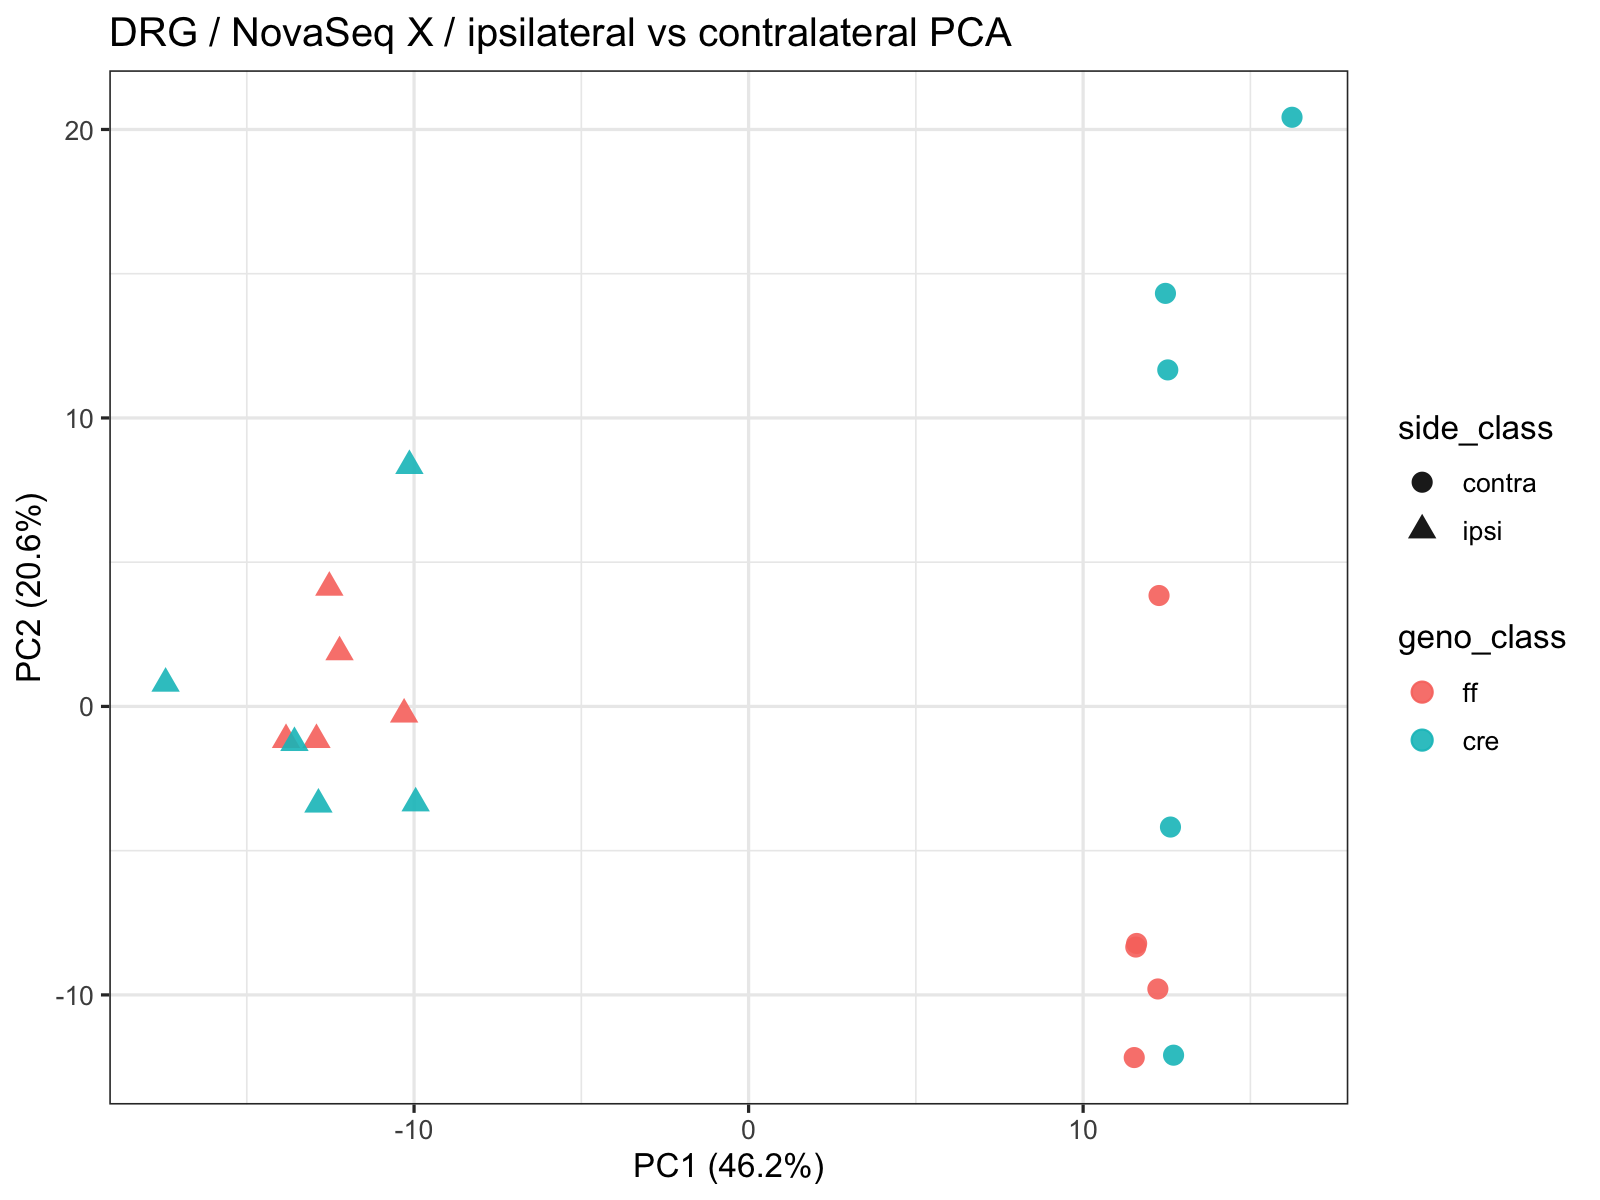

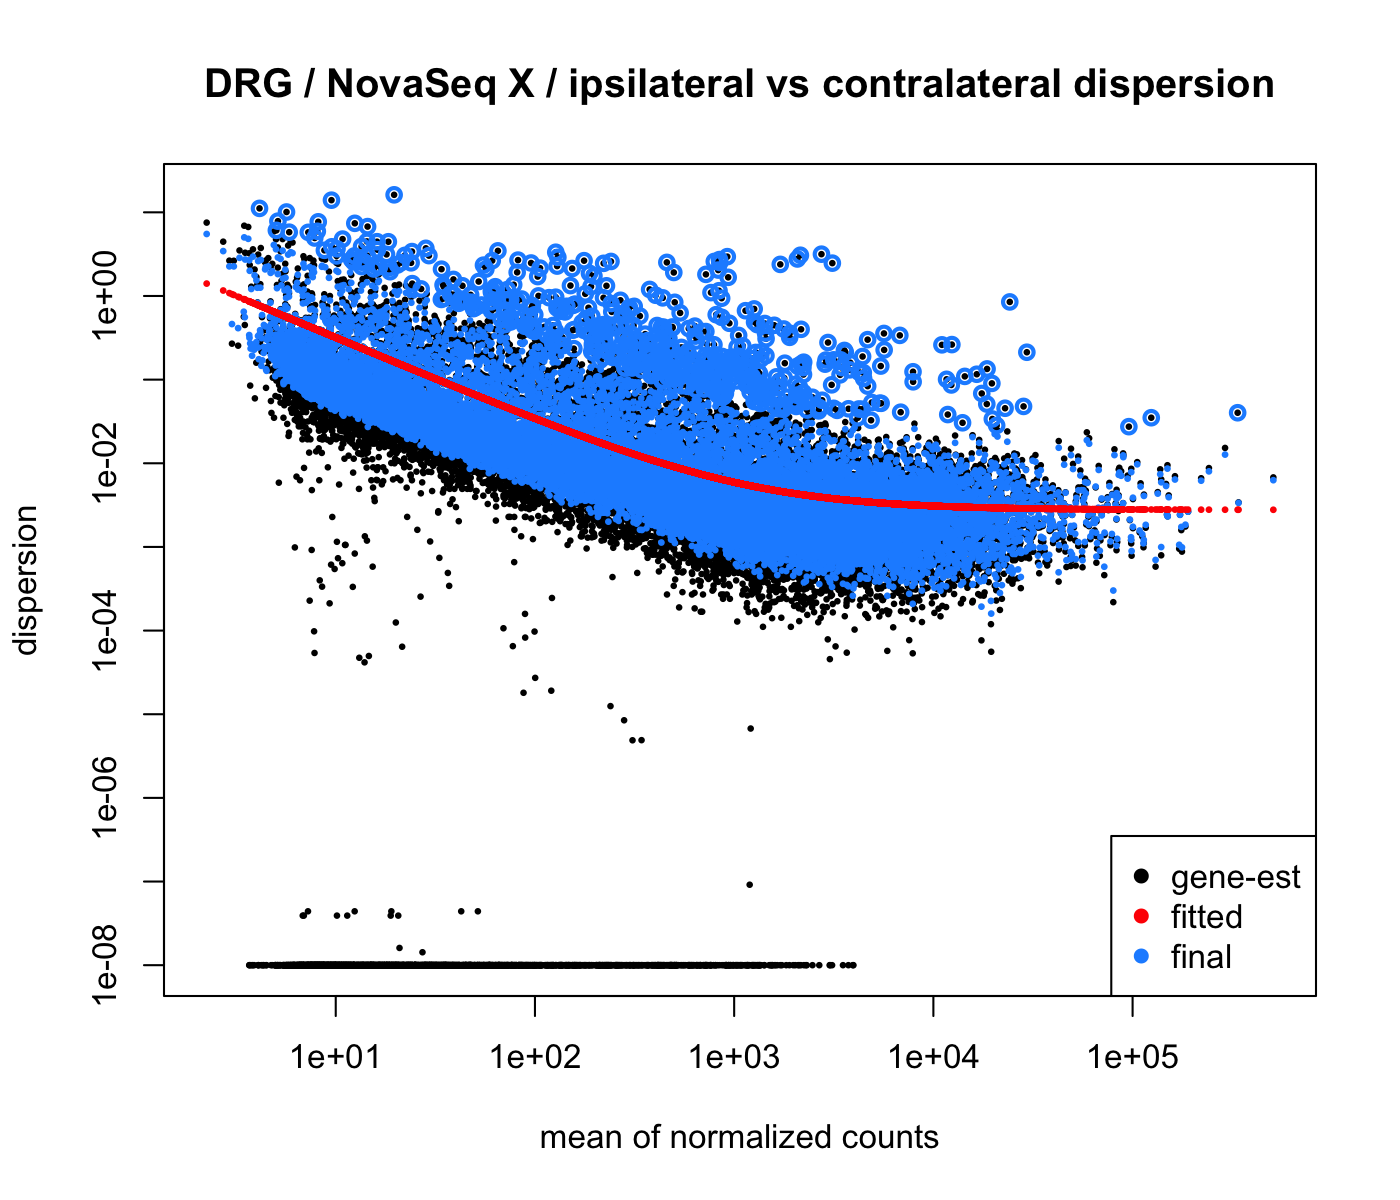

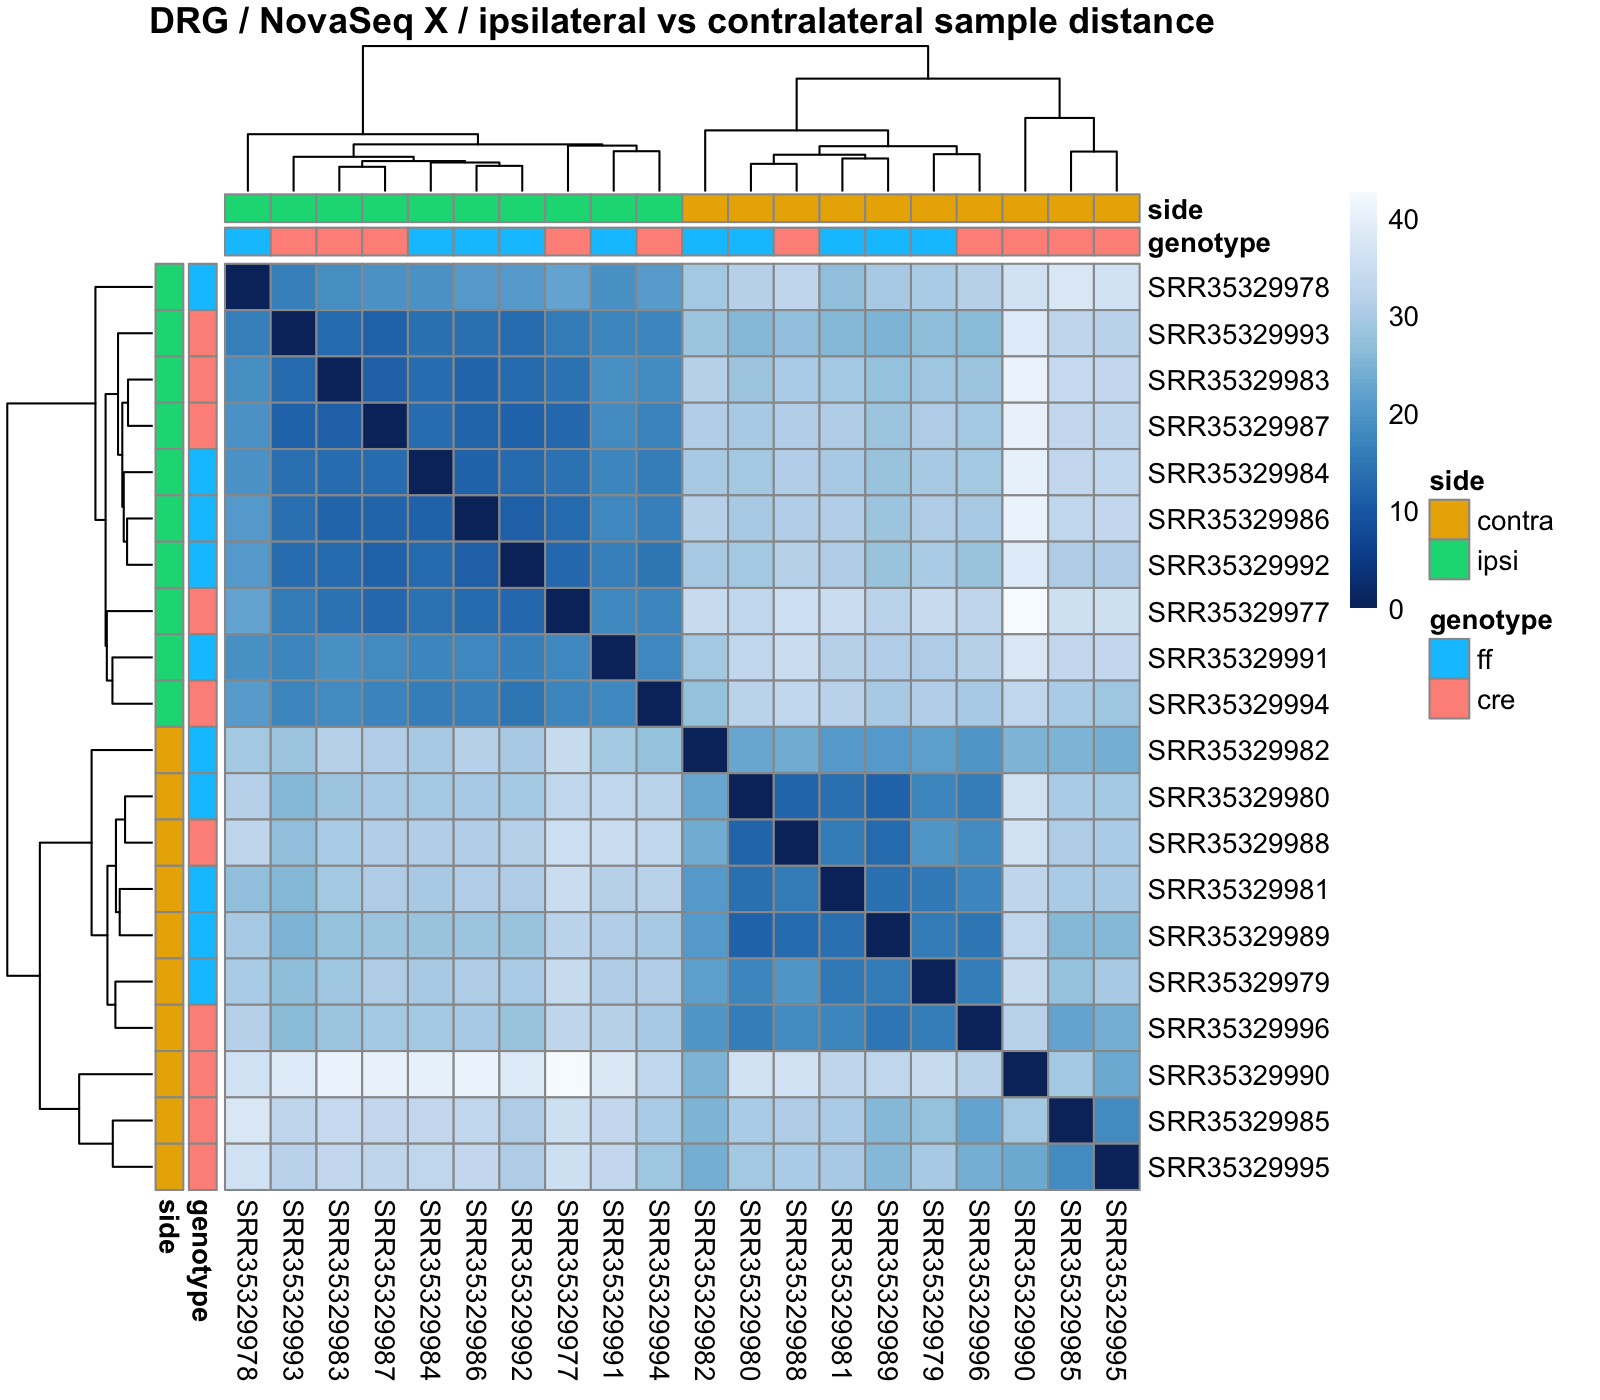

In [4]:
display(Image(filename=str(FIGS / 'pca.png'), width=900))
display(Image(filename=str(FIGS / 'dispersion.png'), width=900))
display(Image(filename=str(FIGS / 'sample_distance_heatmap.png'), width=900))

The main qualitative message is that side (`ipsi` vs `contra`) is the dominant global split in the PCA, while genotype looks more secondary.


## Main contrast previews

These are the easiest files to show when someone asks where the strongest gene-level differences appear.


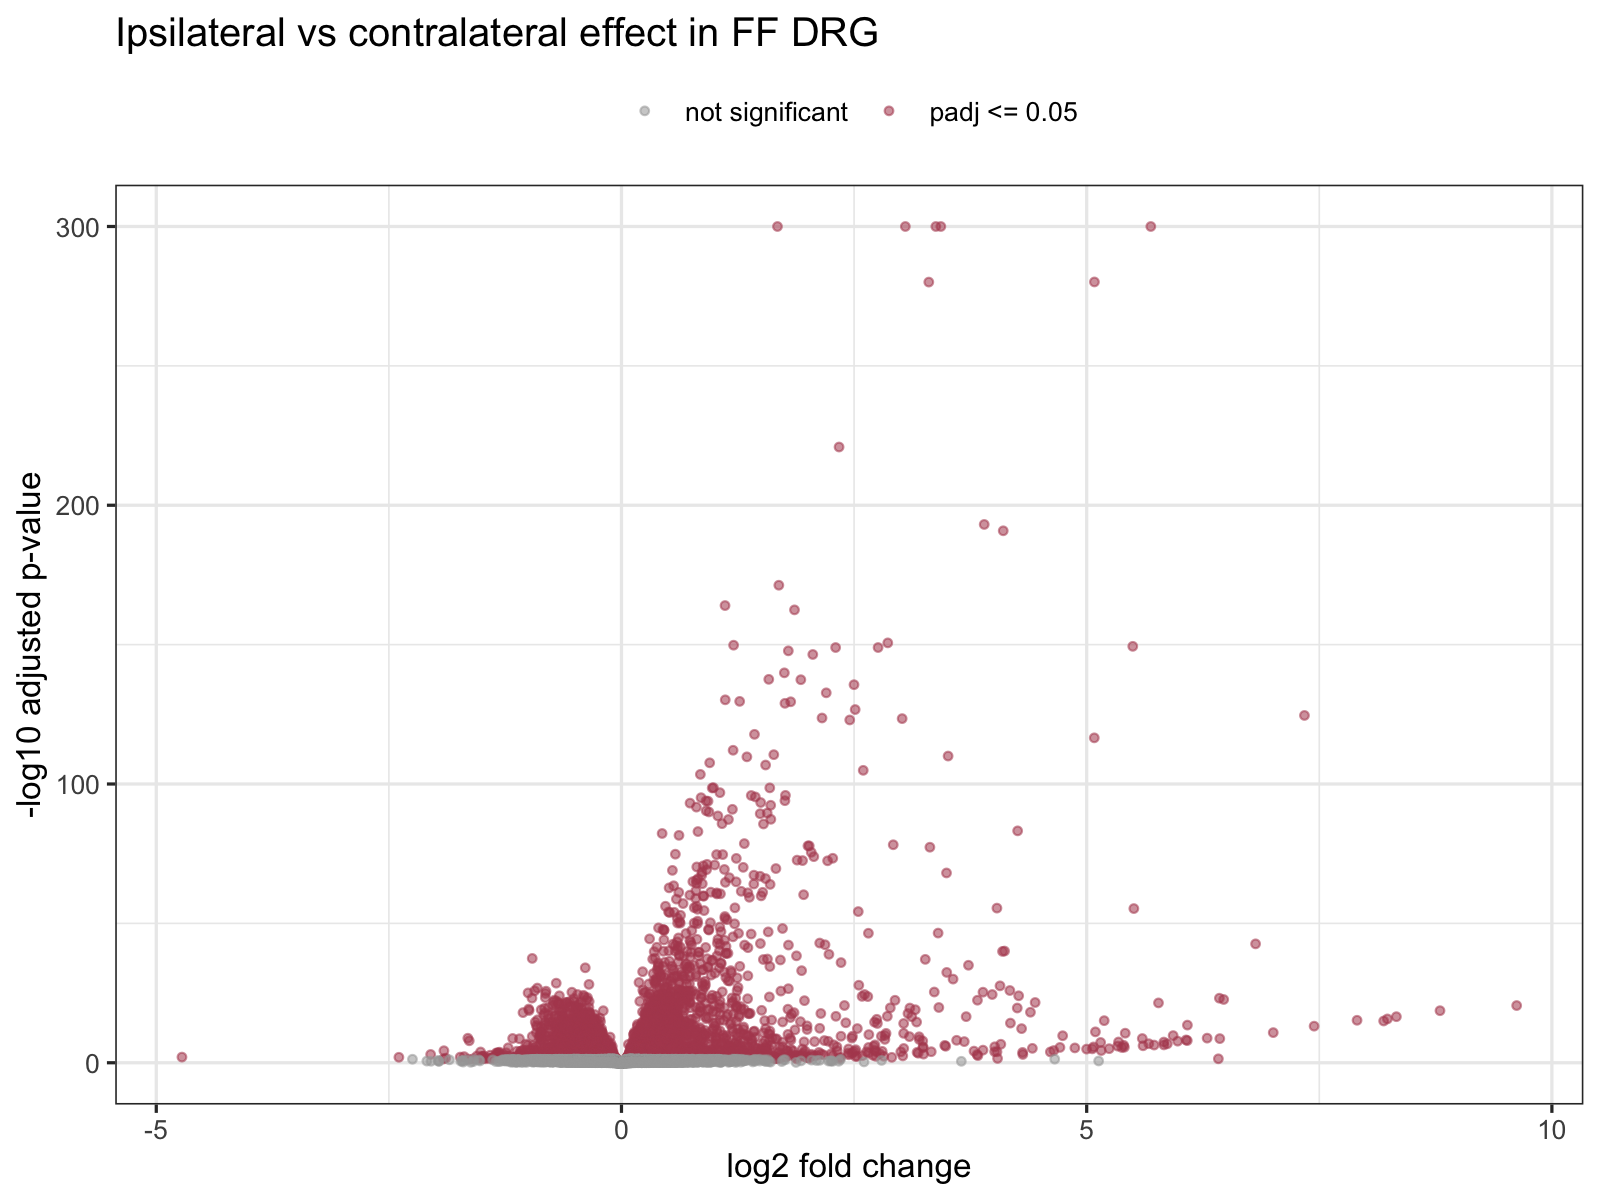

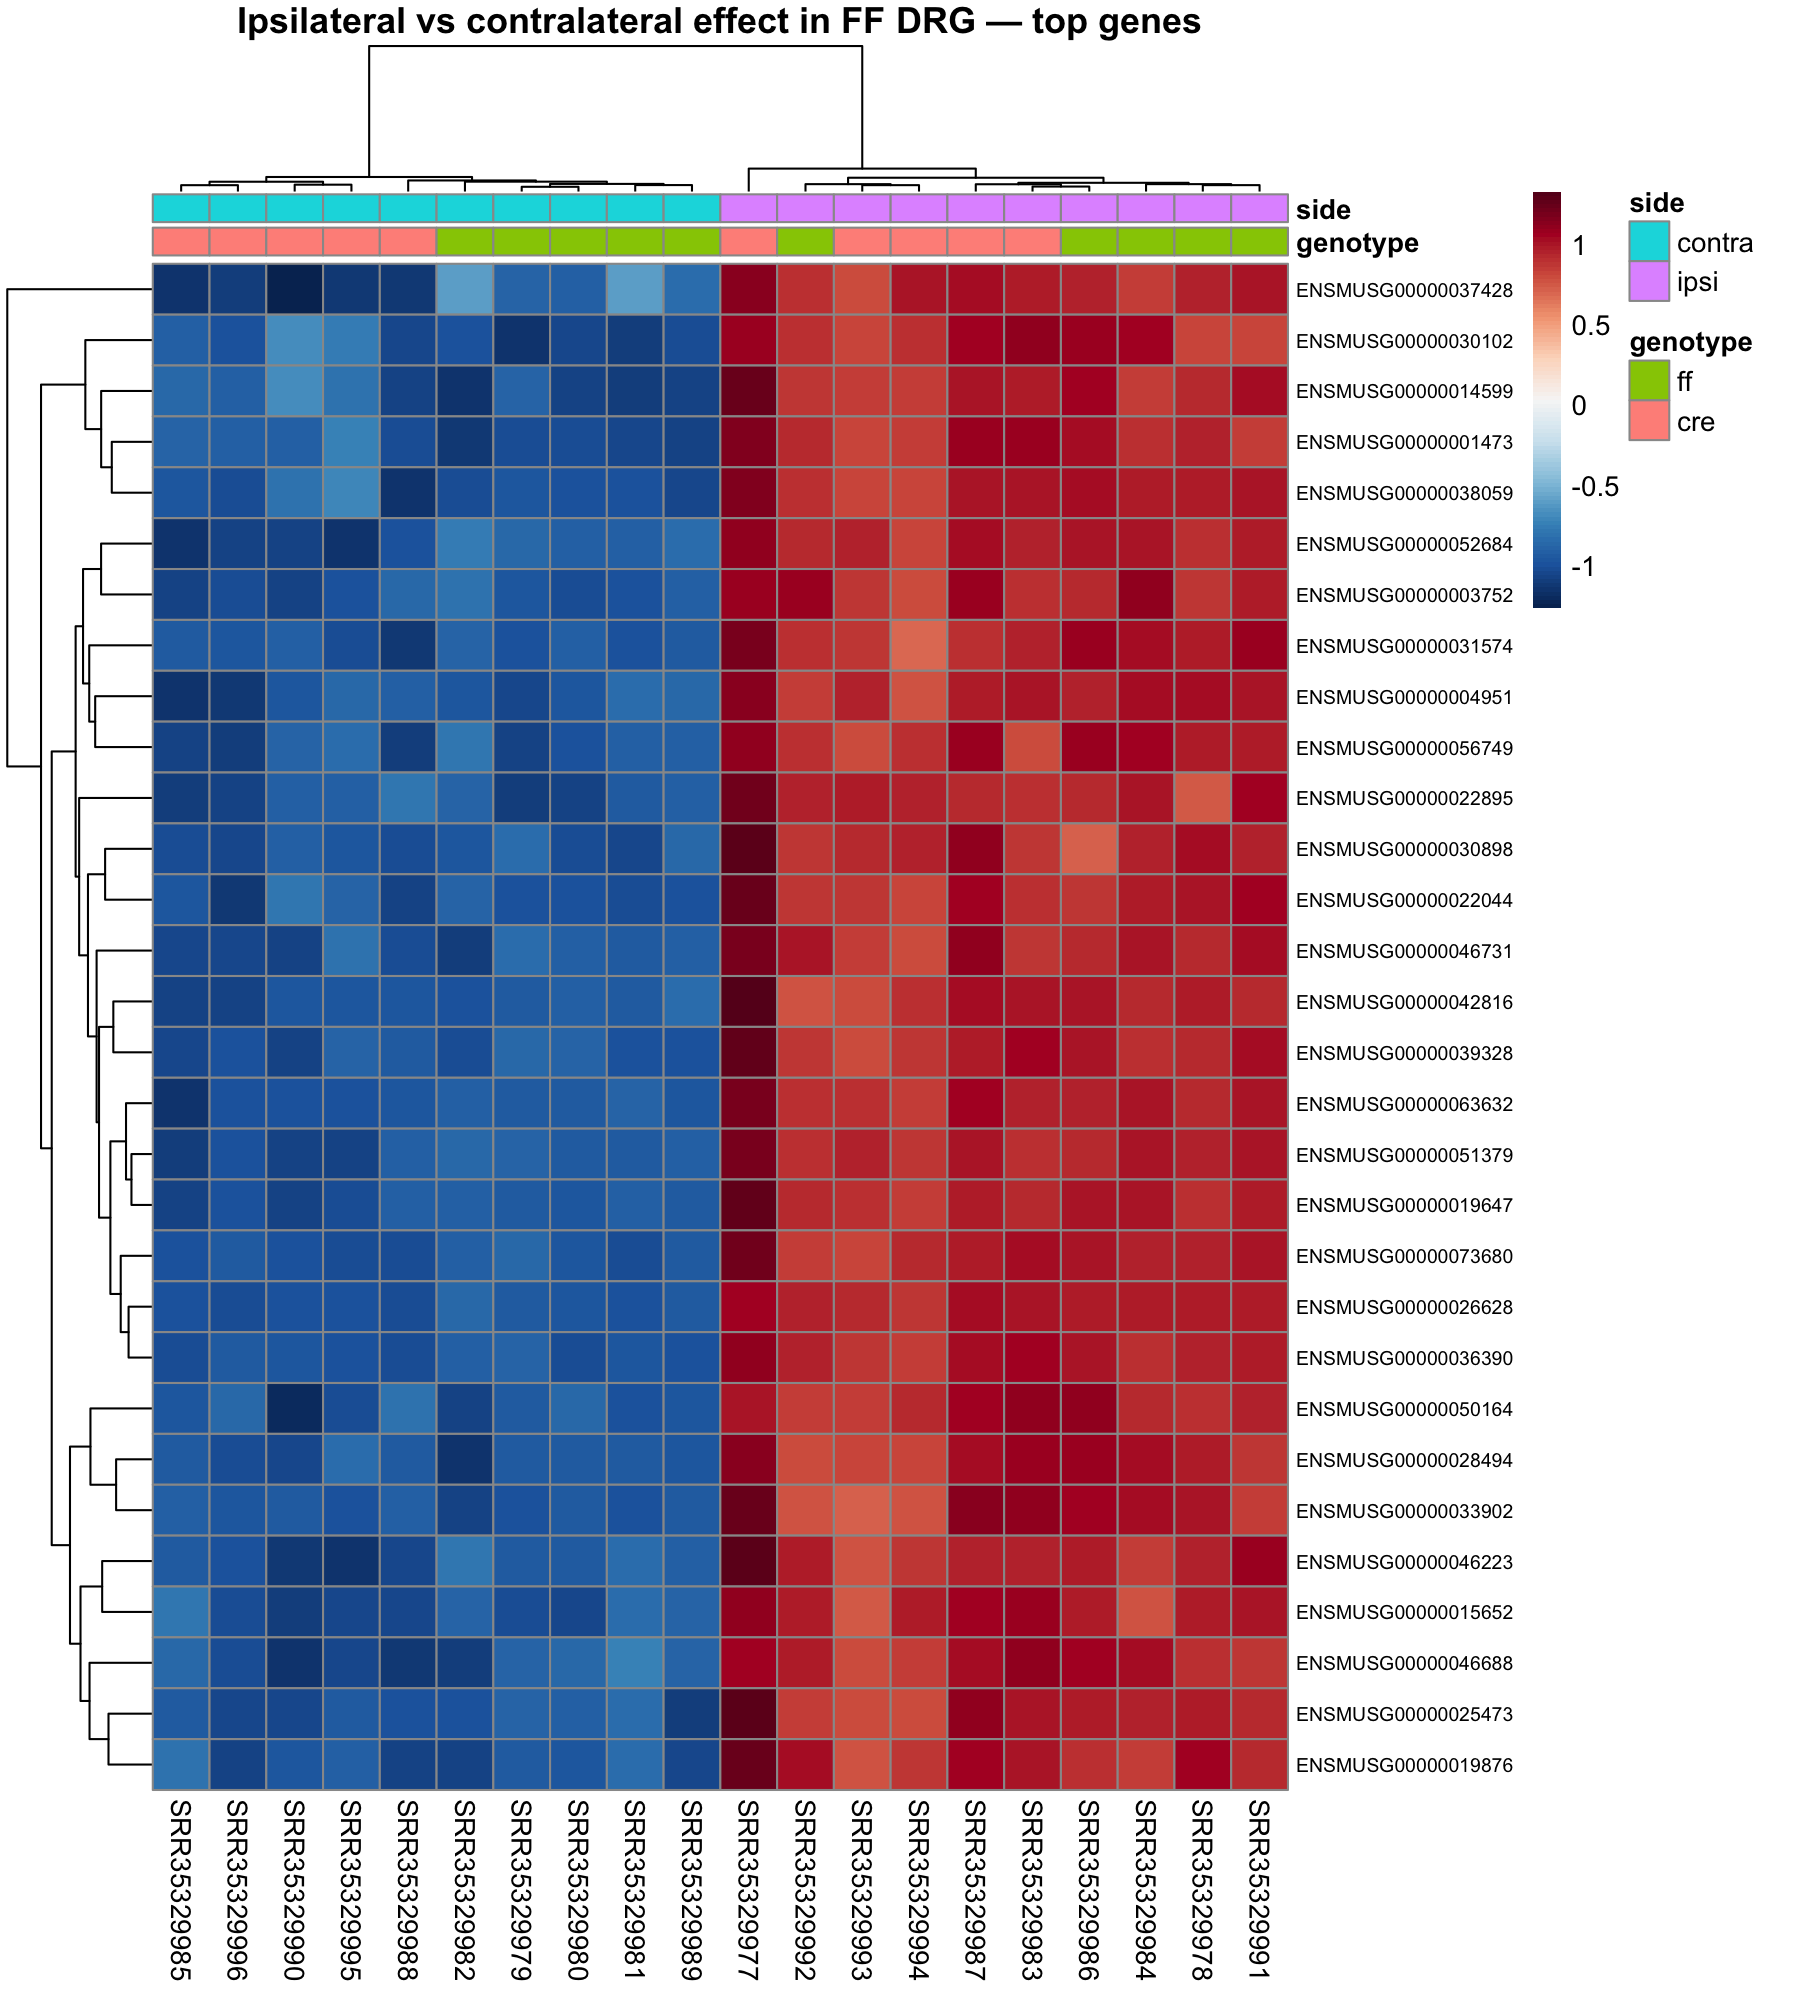

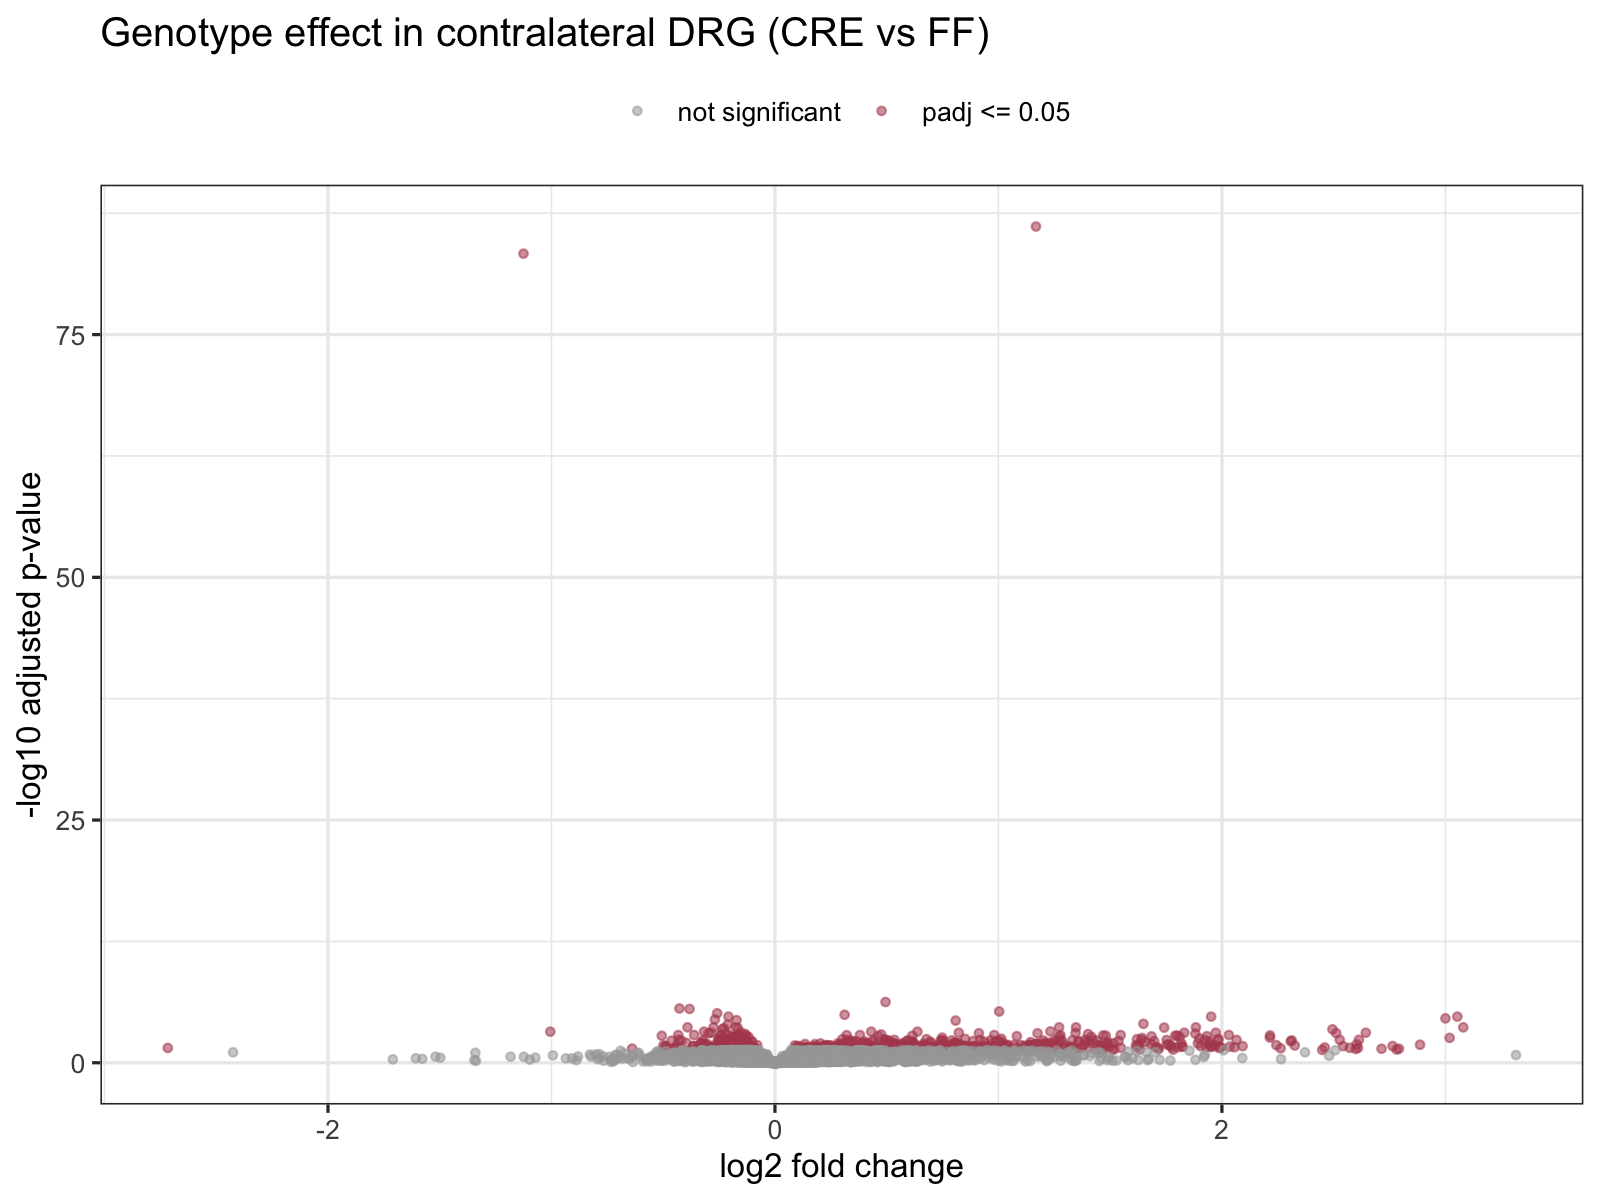

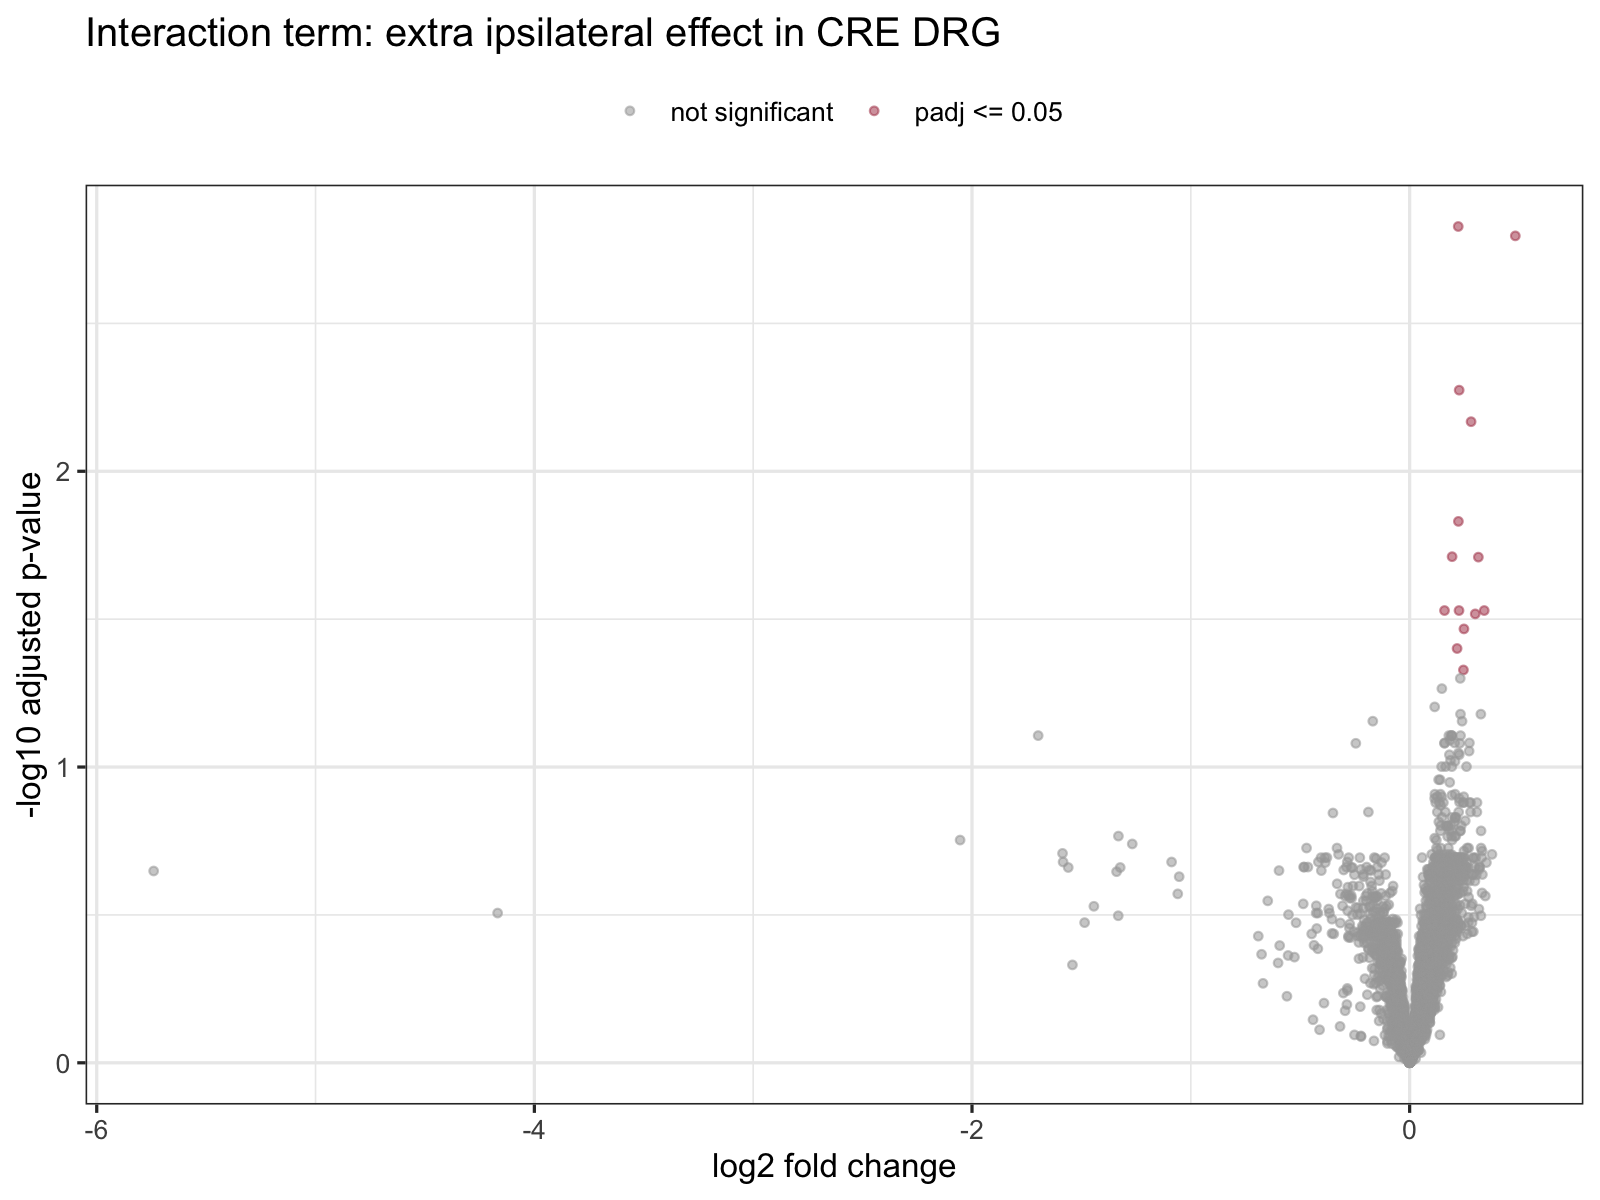

In [5]:
display(Image(filename=str(FTABLES / 'ipsi_vs_contra_in_ff_volcano.png'), width=900))
display(Image(filename=str(FTABLES / 'ipsi_vs_contra_in_ff_heatmap.png'), width=900))
display(Image(filename=str(FTABLES / 'geno_in_contra_volcano.png'), width=900))
display(Image(filename=str(FTABLES / 'interaction_volcano.png'), width=900))

In [6]:
display(pd.read_csv(FTABLES / 'ipsi_vs_contra_in_ff_top_genes.tsv', sep='	').head(20))
display(pd.read_csv(FTABLES / 'ipsi_vs_contra_in_cre_top_genes.tsv', sep='	').head(20))

,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSMUSG00000026628,14650.812564,5.689282,0.092823,61.291737,0.000000e+00,0.000000e+00
1,ENSMUSG00000036390,7407.125832,3.378730,0.072127,46.843856,0.000000e+00,0.000000e+00
2,ENSMUSG00000051379,5691.613725,3.432440,0.086778,39.554351,0.000000e+00,0.000000e+00
3,ENSMUSG00000063632,2497.658471,3.051050,0.080401,37.947933,4.173594e-315,2.239759e-311
4,ENSMUSG00000052684,12732.080048,1.676557,0.044549,37.634234,5.925095e-310,2.543762e-306
5,ENSMUSG00000073680,829.441406,5.083084,0.141051,36.037120,2.194698e-284,7.851898e-281
6,ENSMUSG00000019647,4767.595802,3.302991,0.091674,36.029604,2.877959e-284,8.825467e-281
7,ENSMUSG00000001473,1906.164567,2.338560,0.073022,32.025584,4.803378e-225,1.288866e-221
8,ENSMUSG00000031574,608.571399,3.898638,0.130127,29.960235,3.236989e-197,7.720579e-194
9,ENSMUSG00000042816,871.386731,4.102968,0.137769,29.781510,6.780940e-195,1.455597e-191


,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSMUSG00000026628,14650.812564,5.970877,0.094189,63.392398,0.000000e+00,0.000000e+00
1,ENSMUSG00000036390,7407.125832,3.516284,0.072475,48.516907,0.000000e+00,0.000000e+00
2,ENSMUSG00000051379,5691.613725,3.753422,0.087589,42.852546,0.000000e+00,0.000000e+00
3,ENSMUSG00000052684,12732.080048,1.924662,0.044728,43.030545,0.000000e+00,0.000000e+00
4,ENSMUSG00000063632,2497.658471,3.273226,0.081543,40.140908,0.000000e+00,0.000000e+00
5,ENSMUSG00000019647,4767.595802,3.515638,0.092256,38.107338,9.684882e-318,3.464928e-314
6,ENSMUSG00000073680,829.441406,5.547182,0.154984,35.791973,1.472341e-280,4.515038e-277
7,ENSMUSG00000037428,16683.752209,2.233345,0.068764,32.478465,2.147886e-231,5.763315e-228
8,ENSMUSG00000042816,871.386731,4.657516,0.145085,32.102066,4.125676e-226,9.840195e-223
9,ENSMUSG00000001473,1906.164567,2.178042,0.072611,29.996070,1.104265e-197,2.370416e-194


## Main takeaways

- The `SRP618841` DE run completed for one balanced DRG family on `NovaSeq X`.
- The strongest visible structure is by side (`ipsi` vs `contra`).
- The shared output tree on `sequoia` is:
  - `/home/zebrafish/mouse/SRP618841_parallel/differential_expression_all20`


## Follow-up analysis we are sharing this week

This section brings the main follow-up work from the local `mouse_new` notebook into the shared team notebook. We are only copying the pieces that most directly explain how we are now reading the `SRP618841` differential-expression results.


In [7]:
shared_summary = pd.read_csv(DERIVED / 'analysis_summary.tsv', sep='	')
display(shared_summary[['contrast_id', 'significant_padj_lt_0_05', 'bendpoint_selected', 'bendpoint_threshold']])


,contrast_id,significant_padj_lt_0_05,bendpoint_selected,bendpoint_threshold
0,ipsi_vs_contra_in_ff,7023,709,1.374018e-17
1,ipsi_vs_contra_in_cre,7541,870,8.396838e-17
2,geno_in_contra,891,267,2.134600e-04
3,geno_in_ipsi,2,113,1.434321e-02
4,interaction,14,1823,4.564824e-02


## PCA-first interpretation

We are now reading the dataset structure first. Color marks side class and shape marks genotype, so this view makes it easier to see that side is the dominant organizing axis while genotype is secondary.


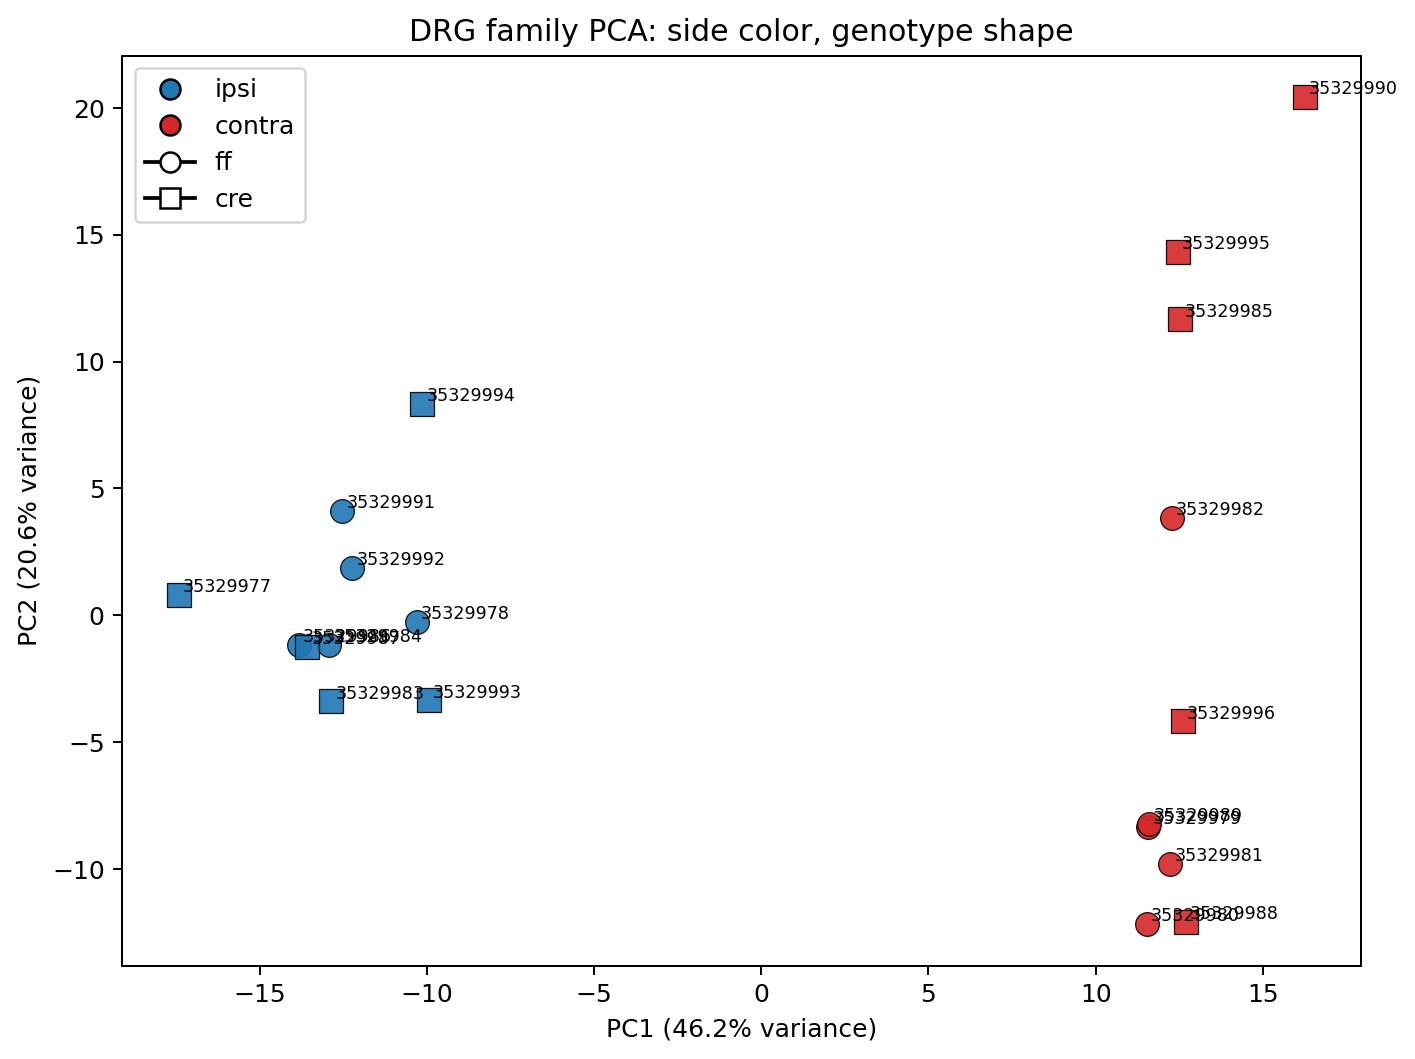

,side_class,ff_srr,cre_srr,pca_distance
0,ipsi,SRR35329986,SRR35329987,0.272240
1,ipsi,SRR35329984,SRR35329987,0.666371
2,contra,SRR35329980,SRR35329988,1.178849
3,ipsi,SRR35329984,SRR35329983,2.239021
4,contra,SRR35329981,SRR35329988,2.342927


In [8]:
display(Image(filename=str(DERIVED / 'family_structure' / 'pca_side_genotype_annotated.png'), width=900))
display(pd.read_csv(DERIVED / 'family_structure' / 'pca_ff_cre_collision_pairs.tsv', sep='	').head(5))


The collision table is helpful because it shows why we are being careful with genotype claims: some `ff` and `cre` samples are still close in PCA space within the same side class, so genotype should not be treated as the main global split.


## Main side-specific follow-up — `ipsi_vs_contra_in_ff`

This is still the cleanest contrast to use when we want to explain the main story. The goal here is not just to show that many genes are significant, but to show how the bend-point method narrows that large signal into a smaller and more interpretable core.


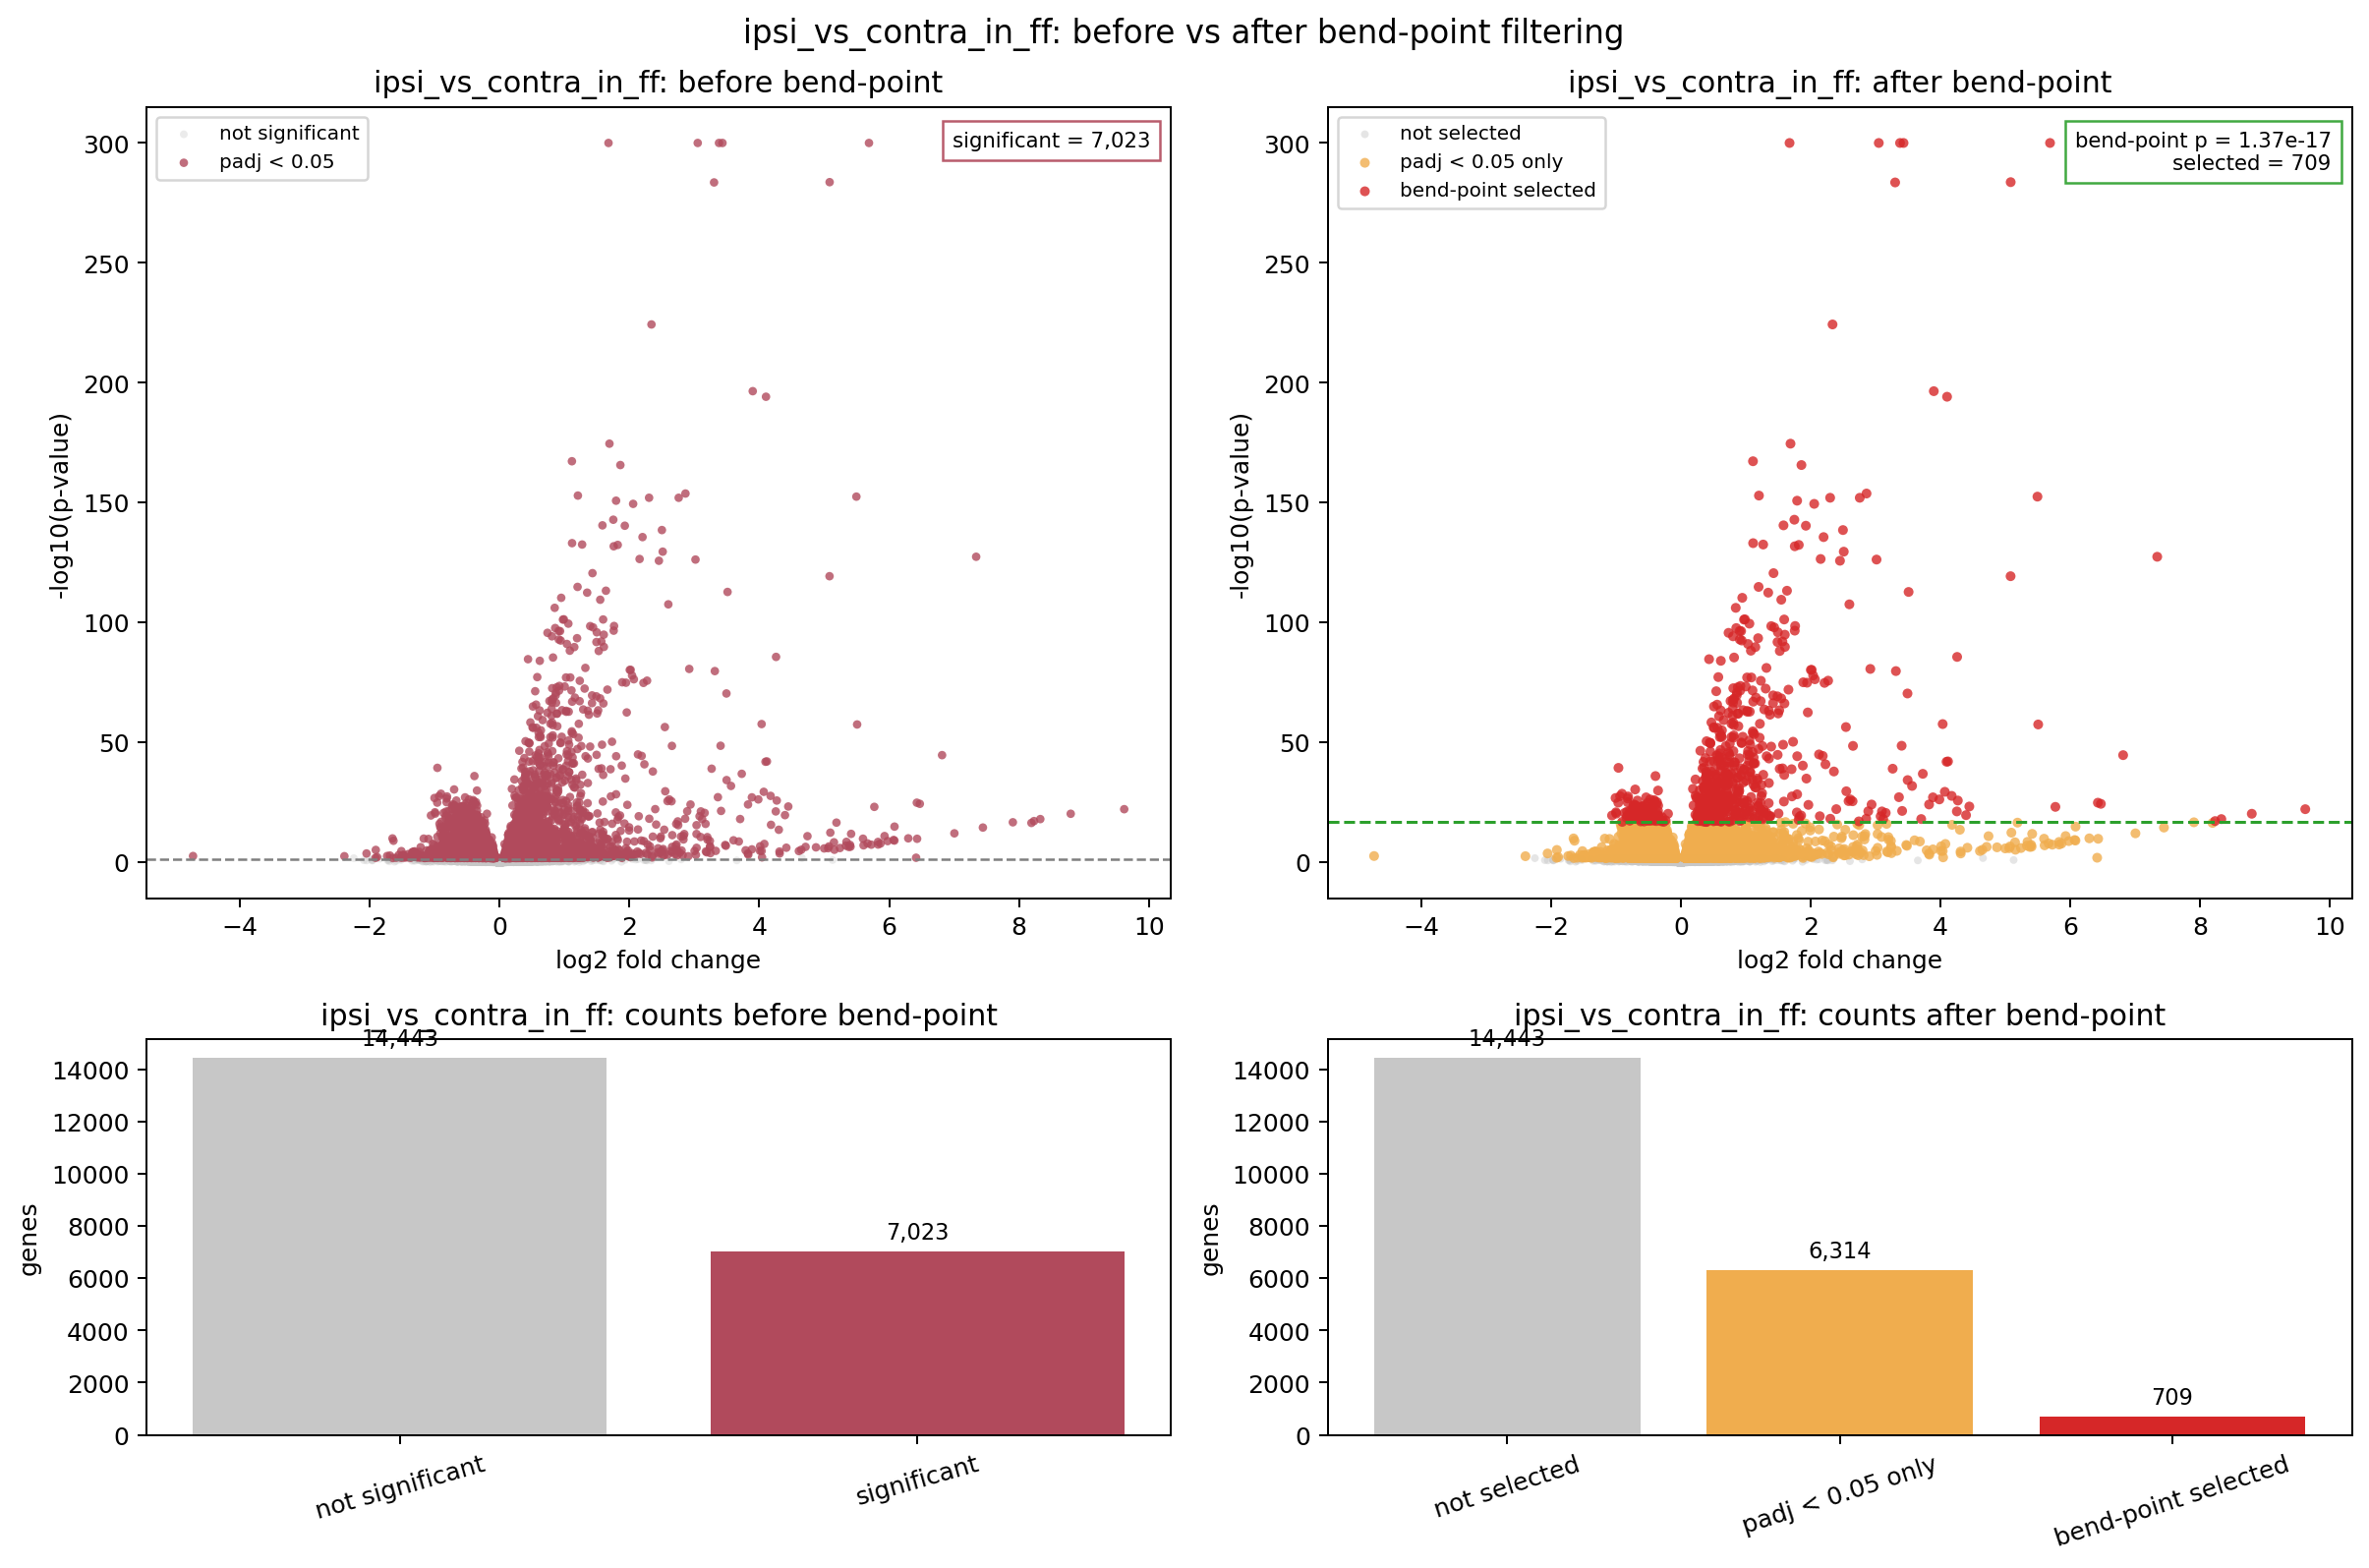

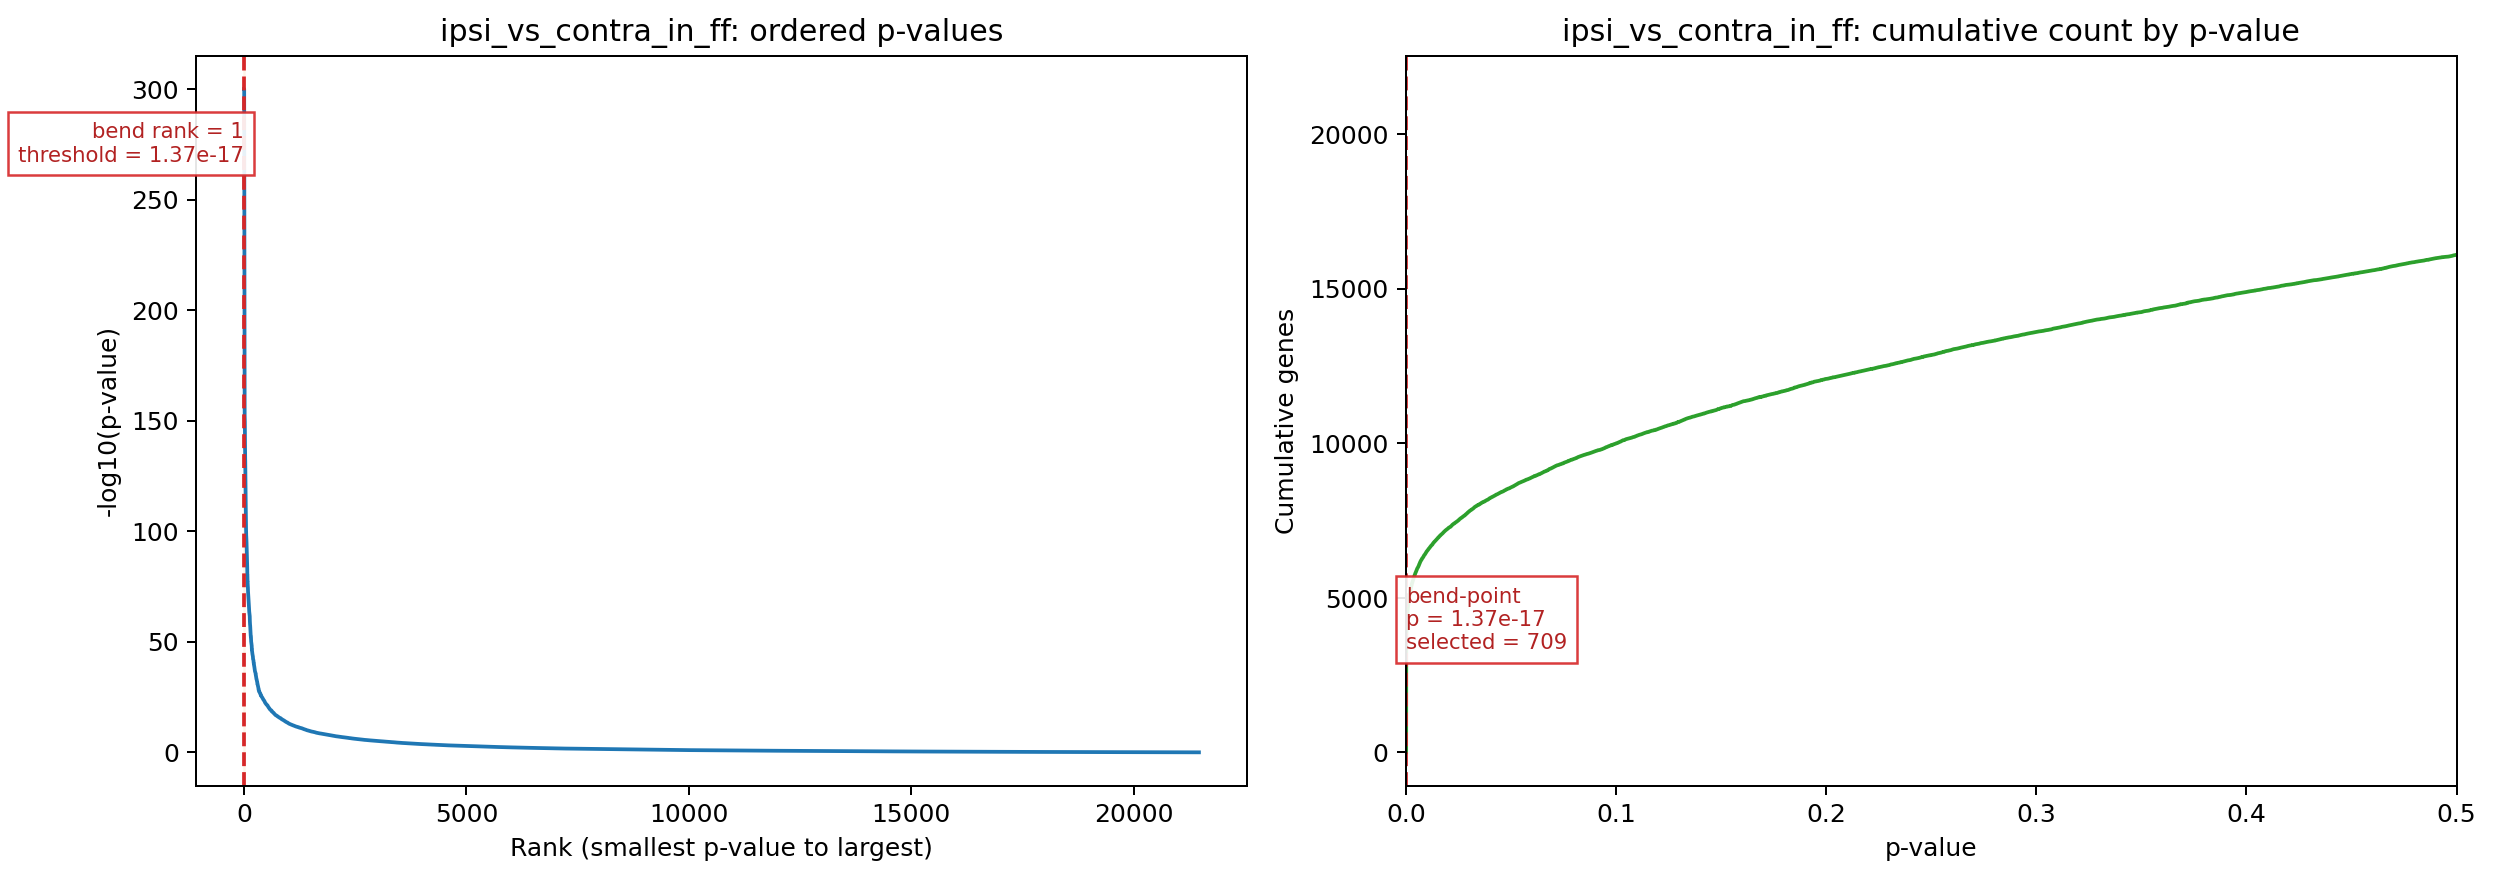

,contrast_id,genes_tested,significant_padj_lt_0_05,bend_pvalue_threshold,genes_below_bendpoint
0,ipsi_vs_contra_in_ff,21466,7023,1.374018e-17,709


,gene_id,pvalue,padj,log2FoldChange,baseMean,rank,rank_frac,neglog10_pvalue,distance_to_line,selected_by_bend
0,ENSMUSG00000026628,0.000000e+00,0.000000e+00,5.689282,14650.812564,1,0.000000,300.000000,0.000000,True
1,ENSMUSG00000036390,0.000000e+00,0.000000e+00,3.378730,7407.125832,2,0.000047,300.000000,0.000047,True
2,ENSMUSG00000051379,0.000000e+00,0.000000e+00,3.432440,5691.613725,3,0.000093,300.000000,0.000093,True
3,ENSMUSG00000063632,4.173594e-315,2.239759e-311,3.051050,2497.658471,4,0.000140,300.000000,0.000140,True
4,ENSMUSG00000052684,5.925095e-310,2.543762e-306,1.676557,12732.080048,5,0.000186,300.000000,0.000186,True
5,ENSMUSG00000073680,2.194698e-284,7.851898e-281,5.083084,829.441406,6,0.000233,283.658625,0.054238,True
6,ENSMUSG00000019647,2.877959e-284,8.825467e-281,3.302991,4767.595802,7,0.000280,283.540915,0.054584,True
7,ENSMUSG00000001473,4.803378e-225,1.288866e-221,2.338560,1906.164567,8,0.000326,224.318453,0.251944,True
8,ENSMUSG00000031574,3.236989e-197,7.720579e-194,3.898638,608.571399,9,0.000373,196.489859,0.344659,True
9,ENSMUSG00000042816,6.780940e-195,1.455597e-191,4.102968,871.386731,10,0.000419,194.168710,0.352350,True


In [9]:
display(Image(filename=str(DERIVED / 'ipsi_vs_contra_in_ff' / 'before_after_selection_comparison.png'), width=1000))
display(Image(filename=str(DERIVED / 'ipsi_vs_contra_in_ff' / 'ordered_pvalue_and_cumulative_curve.png'), width=1000))
display(pd.read_csv(DERIVED / 'ipsi_vs_contra_in_ff' / 'bendpoint_summary.tsv', sep='	'))
display(pd.read_csv(DERIVED / 'ipsi_vs_contra_in_ff' / 'selected_genes_bendpoint.tsv', sep='	').head(15))


The before/after figure shows the same contrast before and after bend-point filtering, while the ordered-`p` curve makes the cutoff logic explicit. We are using this to say that the side-specific signal remains strong even after we stop treating the full significant list as one undifferentiated block.


## Secondary genotype follow-up — `geno_in_contra`

This is the genotype branch we want the team to keep in mind as supporting context. It is weaker than the side-specific signal, but it still has a non-zero interpretable core, which is clearer once we look at the bend-point view and the effect-size zoom together.


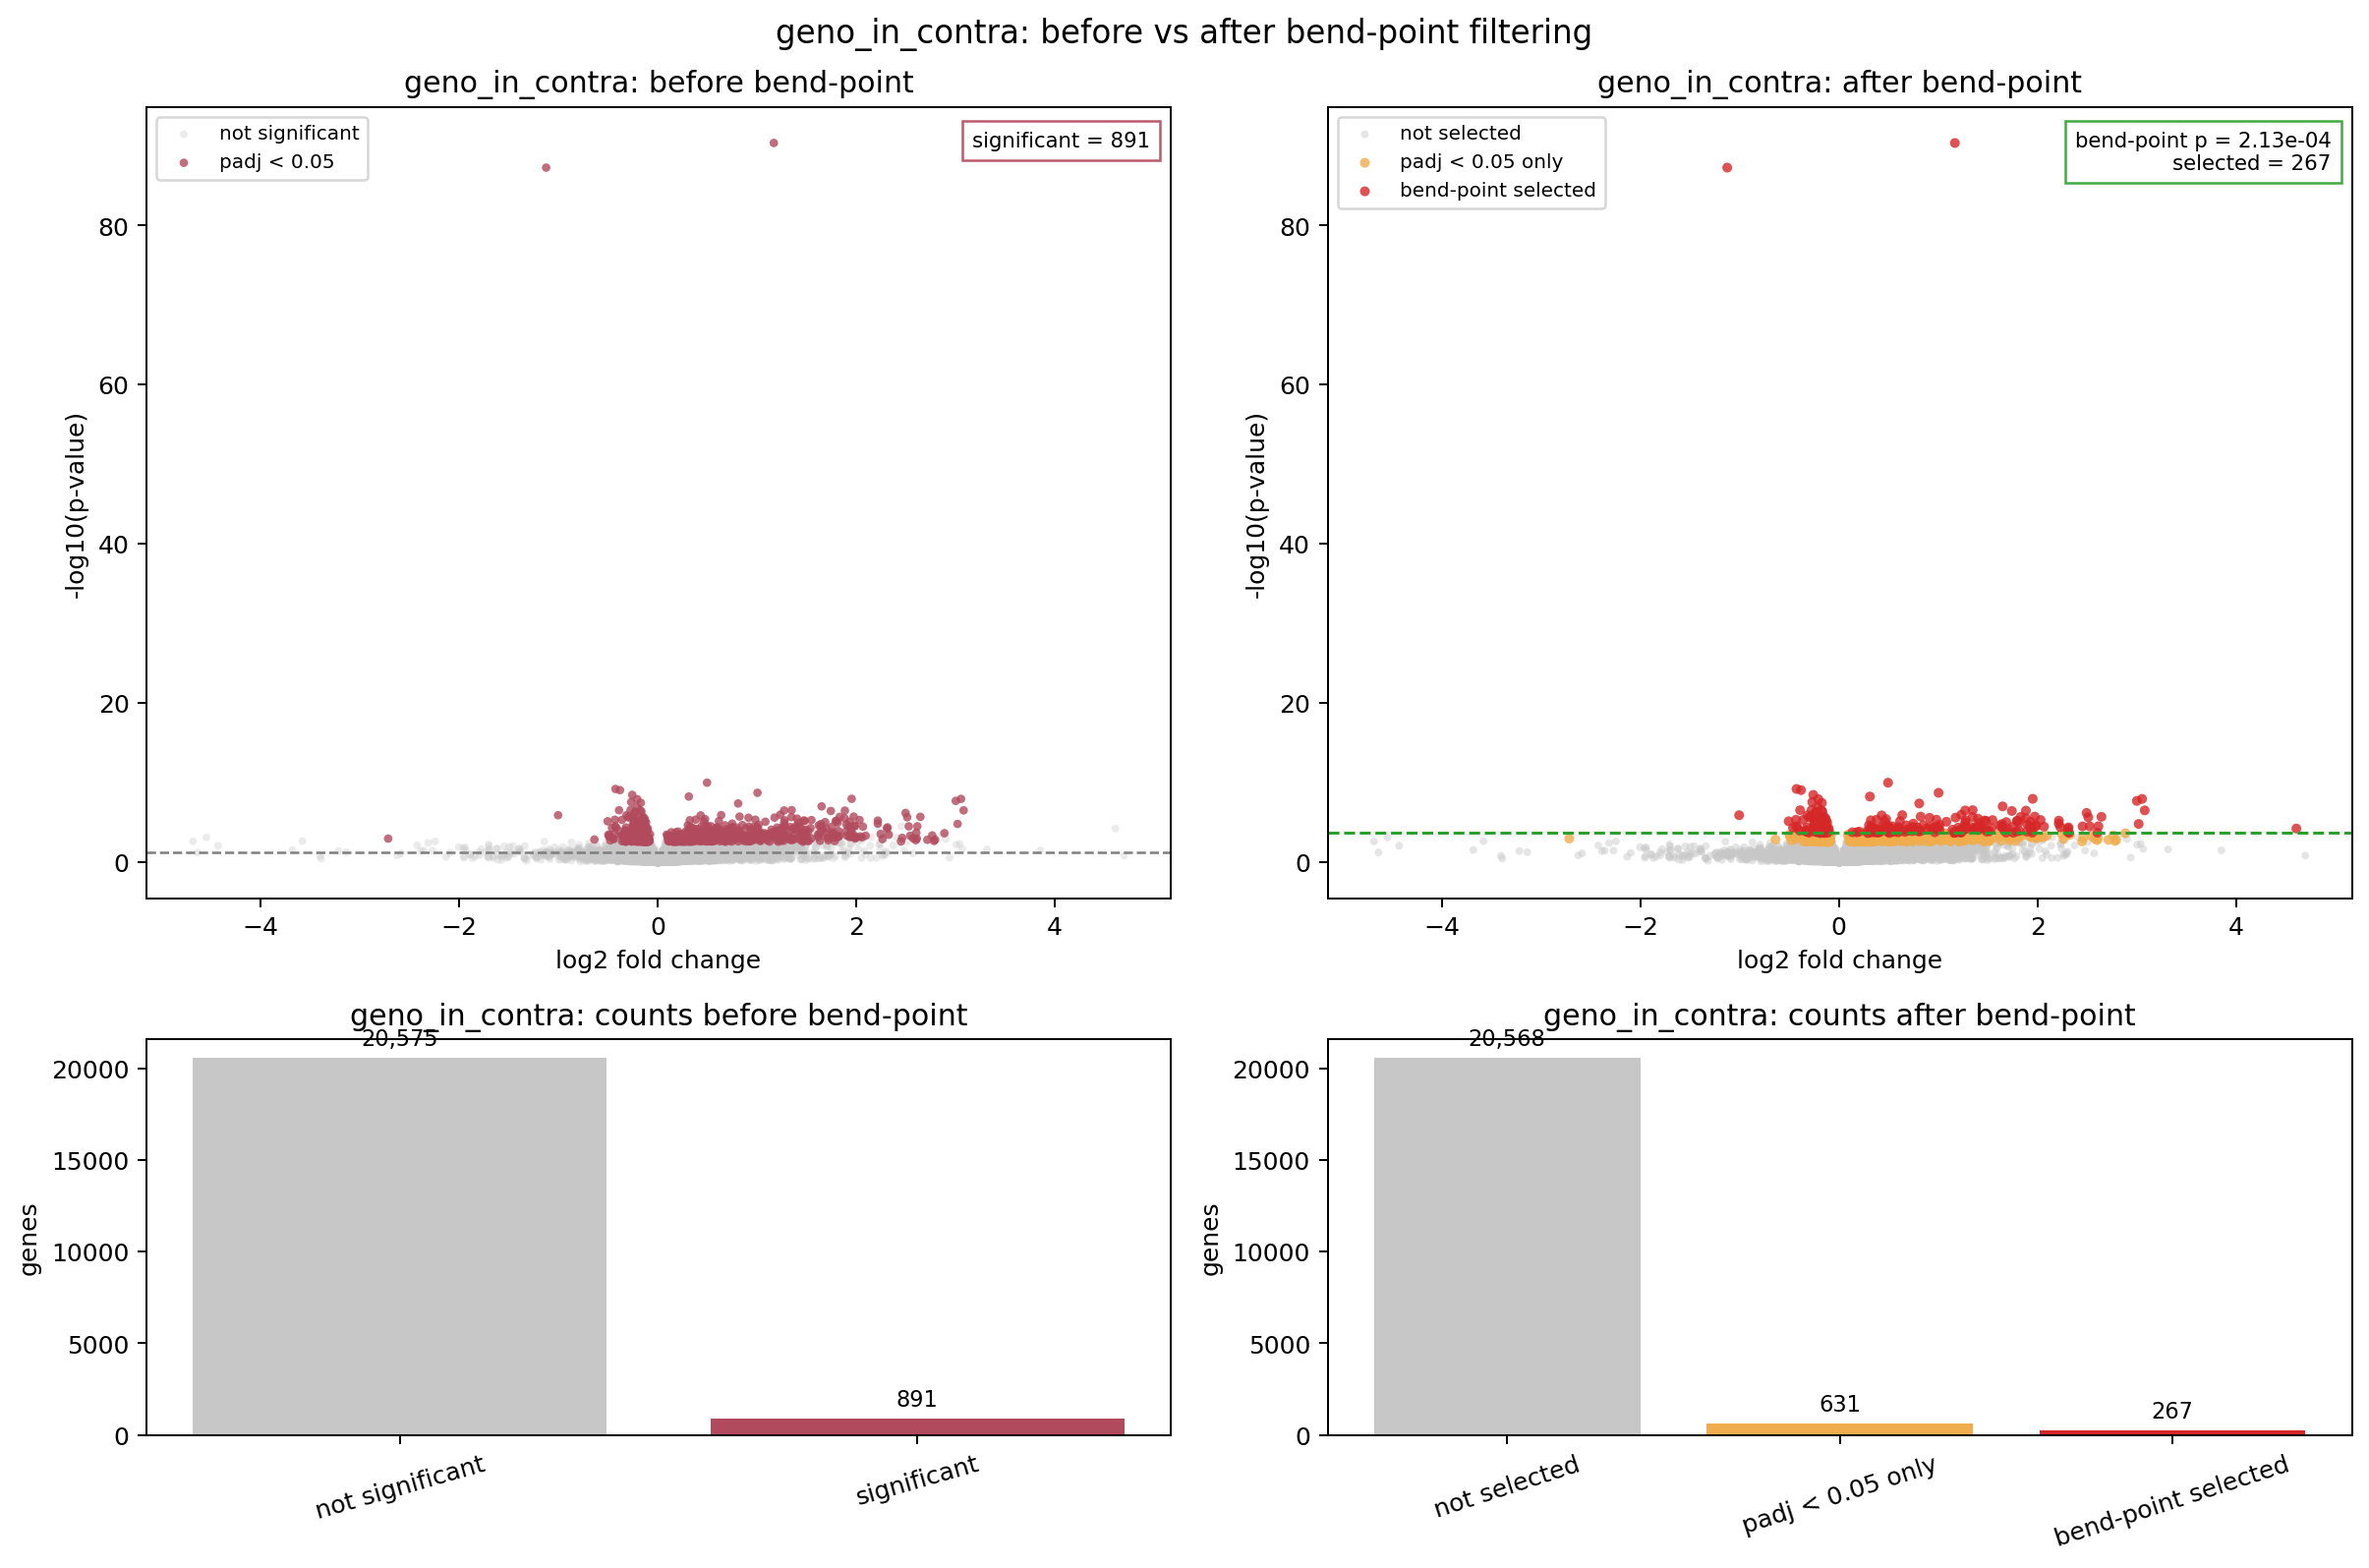

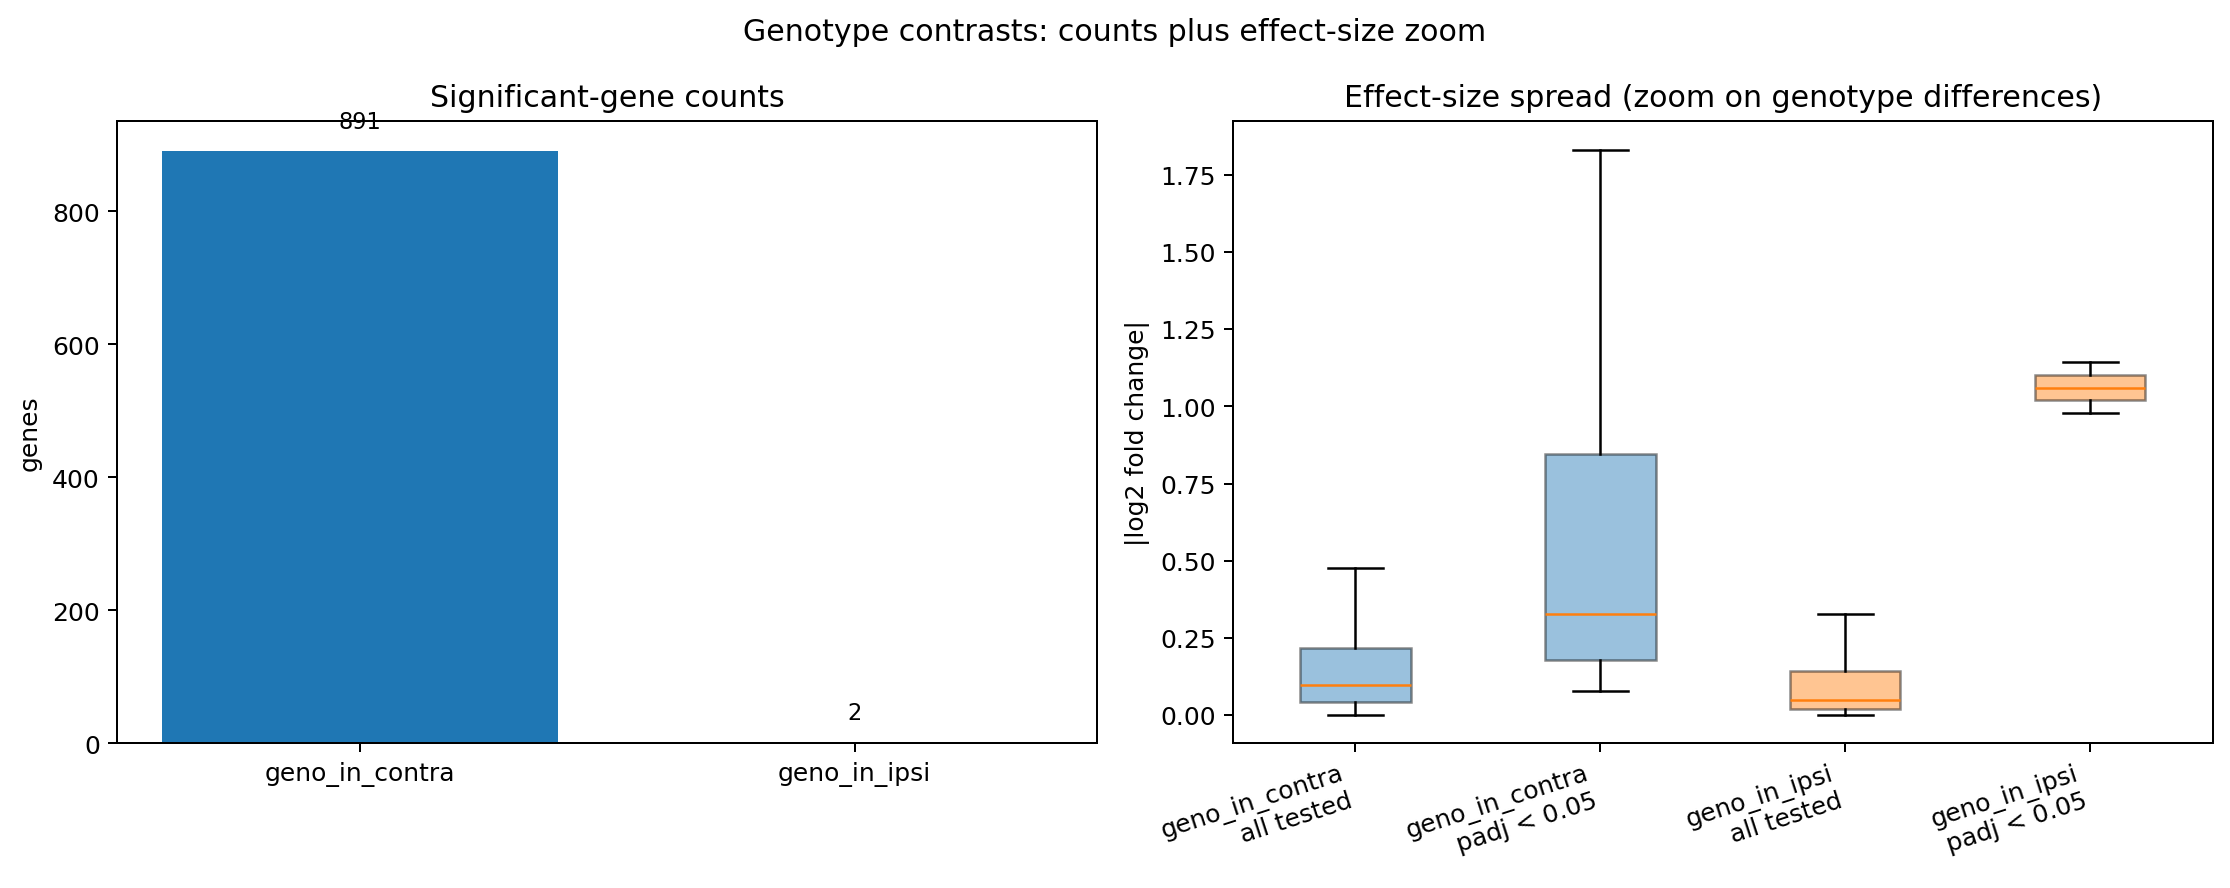

,contrast_id,genes_tested,significant_padj_lt_0_05,bend_pvalue_threshold,genes_below_bendpoint
0,geno_in_contra,21466,891,0.000213,267


,gene_id,pvalue,padj,log2FoldChange,baseMean,rank,rank_frac,neglog10_pvalue,distance_to_line,selected_by_bend
0,ENSMUSG00000032011,4.329322e-91,7.312658e-87,1.167886,85101.054172,1,0.000000,90.363580,0.000000,True
1,ENSMUSG00000054423,5.428531e-88,4.584666e-84,-1.125242,26411.196648,2,0.000047,87.265318,0.034238,True
2,ENSMUSG00000071547,9.856686e-11,5.549643e-07,0.494899,290.058023,3,0.000093,10.006269,0.889119,True
3,ENSMUSG00000037428,6.029351e-10,2.546044e-06,-0.427349,16683.752209,4,0.000140,9.219729,0.897776,True
4,ENSMUSG00000021721,8.455688e-10,2.856500e-06,-0.381872,736.109370,5,0.000186,9.072851,0.899355,True
5,ENSMUSG00000066113,1.835970e-09,5.168561e-06,1.003391,343.552194,6,0.000233,8.736135,0.903034,True
6,ENSMUSG00000021675,3.332729e-09,8.041875e-06,-0.258542,6807.005301,7,0.000280,8.477200,0.905853,True
7,ENSMUSG00000034910,5.399490e-09,1.140035e-05,0.311732,626.124838,8,0.000326,8.267647,0.908125,True
8,ENSMUSG00000037362,1.039161e-08,1.766397e-05,1.951837,3474.041675,9,0.000373,7.983317,0.911225,True
9,ENSMUSG00000039084,1.076337e-08,1.766397e-05,3.053604,281.172985,10,0.000419,7.968052,0.911347,True


In [10]:
display(Image(filename=str(DERIVED / 'geno_in_contra' / 'before_after_selection_comparison.png'), width=1000))
display(Image(filename=str(DERIVED / 'genotype_comparison' / 'geno_counts_and_boxplot_zoom.png'), width=1000))
display(pd.read_csv(DERIVED / 'geno_in_contra' / 'bendpoint_summary.tsv', sep='	'))
display(pd.read_csv(DERIVED / 'geno_in_contra' / 'selected_genes_bendpoint.tsv', sep='	').head(15))


This is the main supporting genotype result we would share with the team right now. It helps us keep genotype in the discussion without over-claiming that it is the primary structure of the dataset.


## Enrichment snapshots for team discussion

We are keeping one compact enrichment snapshot for the main side-specific story and one for the supporting genotype branch so the team can see the broad biological themes without drowning in repetitive plots.


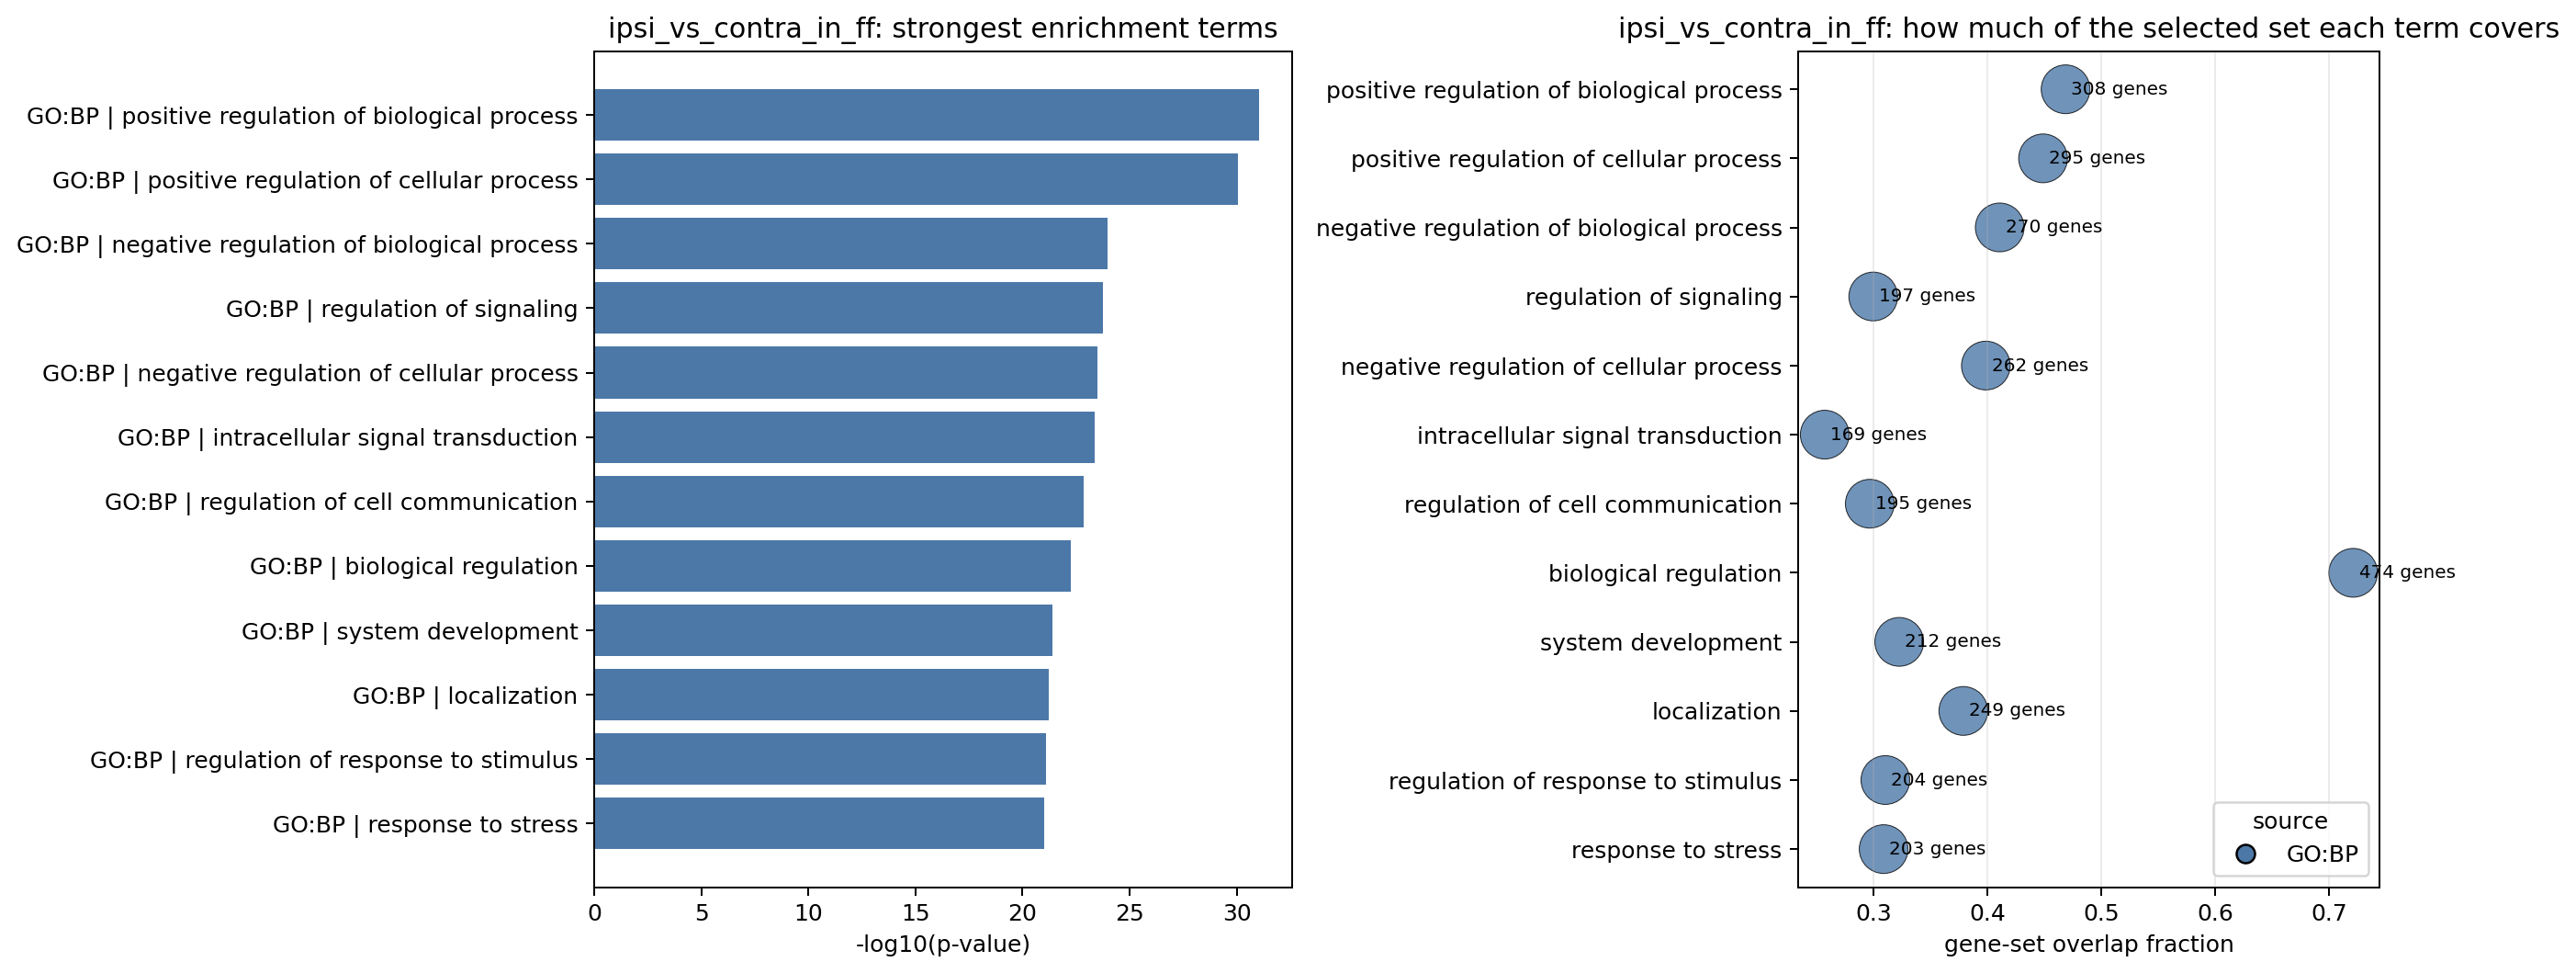

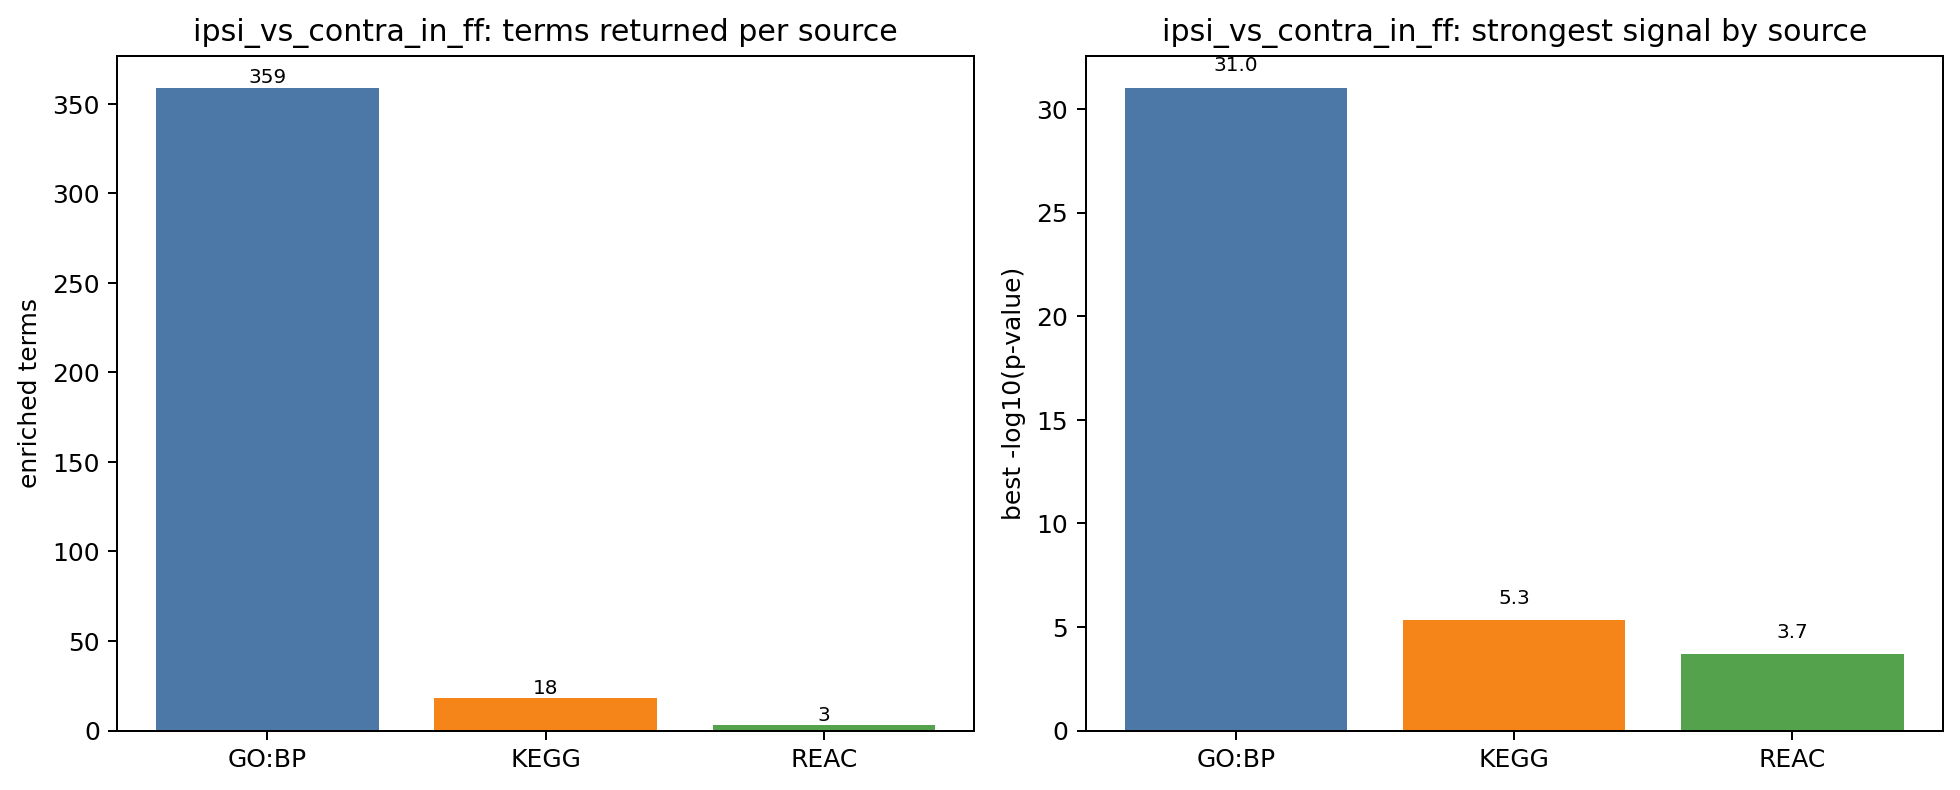

,source,name,p_value,intersection_size,effective_domain_size
0,GO:BP,positive regulation of biological process,9.427224e-32,308,25907
1,GO:BP,positive regulation of cellular process,8.454629e-31,295,25907
2,GO:BP,negative regulation of biological process,1.114633e-24,270,25907
3,GO:BP,regulation of signaling,1.717882e-24,197,25907
4,GO:BP,negative regulation of cellular process,3.268086e-24,262,25907
5,GO:BP,intracellular signal transduction,4.320748e-24,169,25907
6,GO:BP,regulation of cell communication,1.429176e-23,195,25907
7,GO:BP,biological regulation,5.557276e-23,474,25907
8,GO:BP,system development,3.999491e-22,212,25907
9,GO:BP,localization,6.068204e-22,249,25907


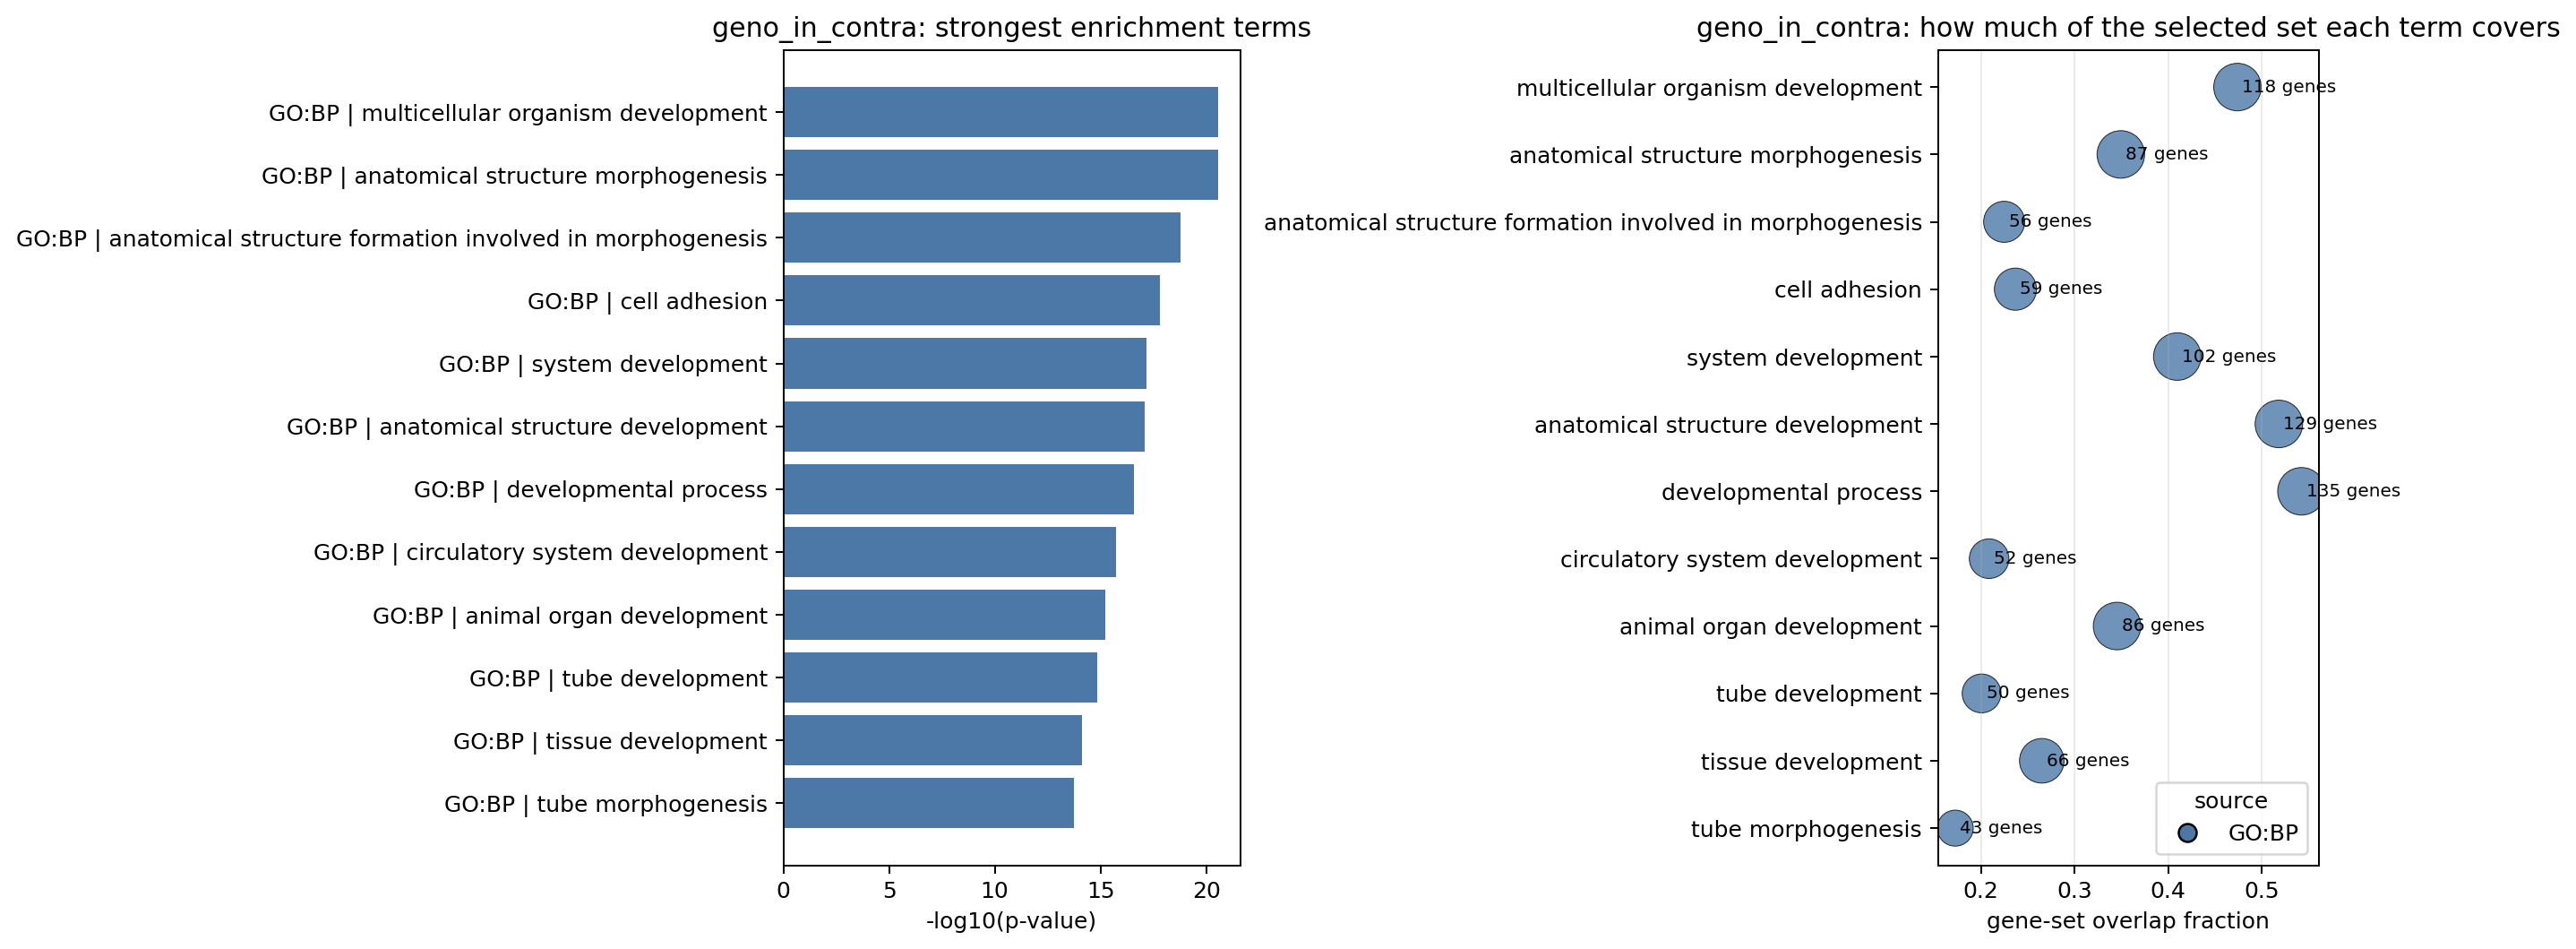

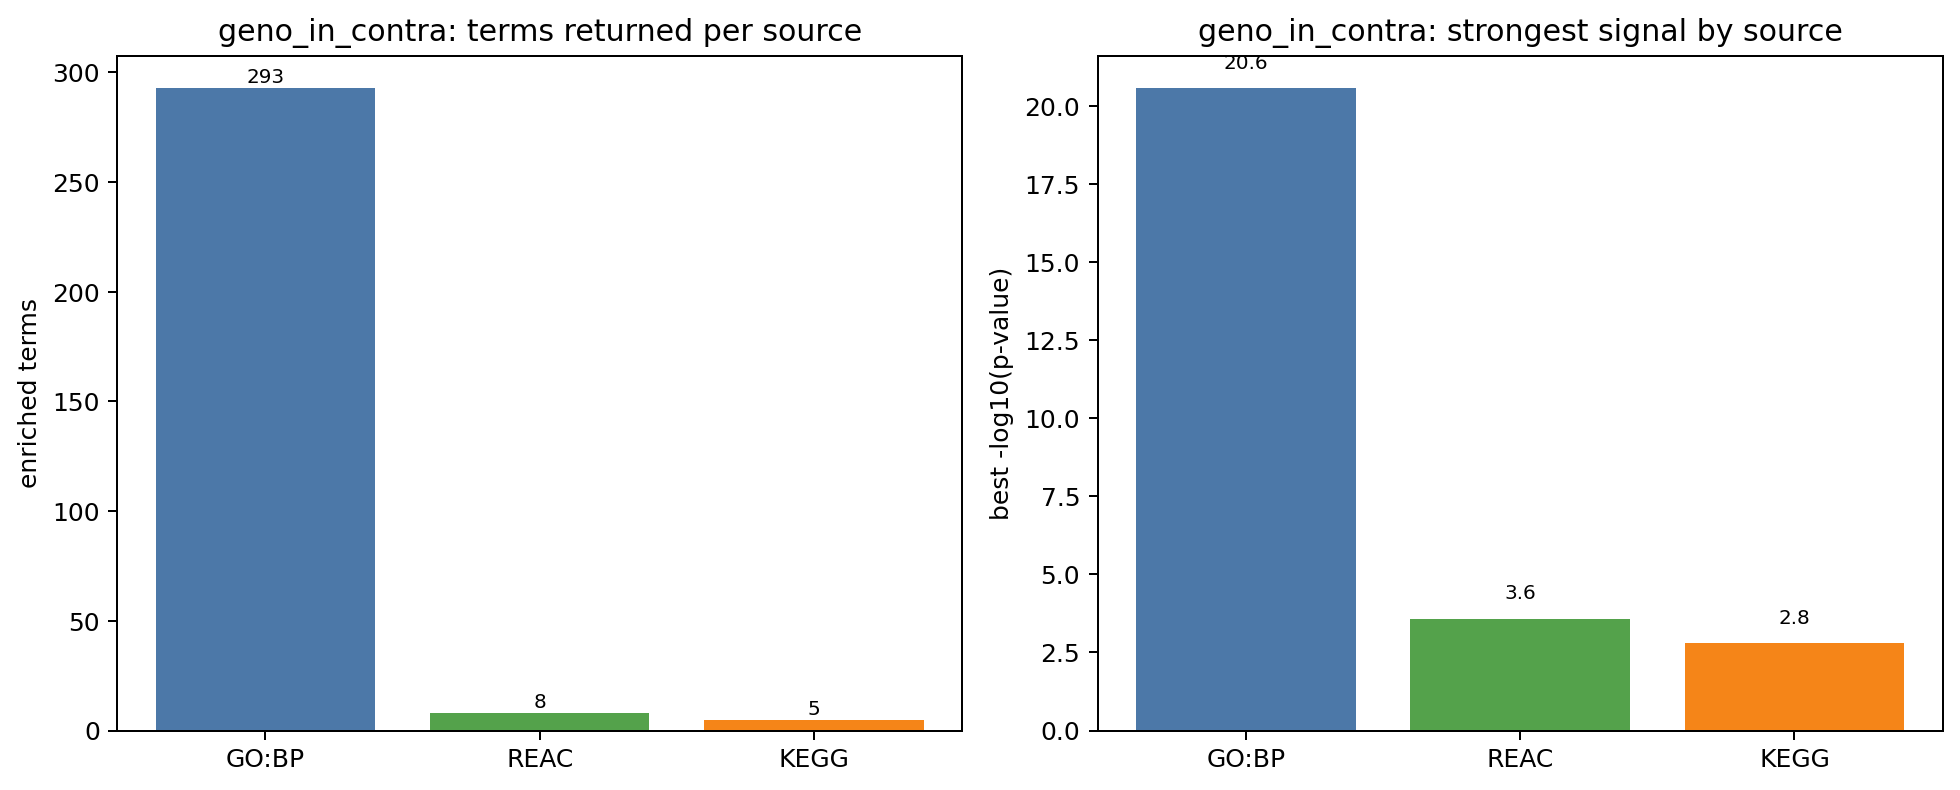

,source,name,p_value,intersection_size,effective_domain_size
0,GO:BP,multicellular organism development,2.626361e-21,118,25907
1,GO:BP,anatomical structure morphogenesis,2.773581e-21,87,25907
2,GO:BP,anatomical structure formation involved in mor...,1.639167e-19,56,25907
3,GO:BP,cell adhesion,1.486456e-18,59,25907
4,GO:BP,system development,6.619093e-18,102,25907
5,GO:BP,anatomical structure development,8.507661e-18,129,25907
6,GO:BP,developmental process,2.714760e-17,135,25907
7,GO:BP,circulatory system development,1.891758e-16,52,25907
8,GO:BP,animal organ development,5.811260e-16,86,25907
9,GO:BP,tube development,1.406504e-15,50,25907


In [11]:
display(Image(filename=str(DERIVED / 'ipsi_vs_contra_in_ff' / 'gprofiler_terms_and_overlap.png'), width=1000))
display(Image(filename=str(DERIVED / 'ipsi_vs_contra_in_ff' / 'gprofiler_source_summary.png'), width=850))
display(pd.read_csv(DERIVED / 'ipsi_vs_contra_in_ff' / 'gprofiler_enrichment.tsv', sep='	')[['source','name','p_value','intersection_size','effective_domain_size']].head(10))
display(Image(filename=str(DERIVED / 'geno_in_contra' / 'gprofiler_terms_and_overlap.png'), width=1000))
display(Image(filename=str(DERIVED / 'geno_in_contra' / 'gprofiler_source_summary.png'), width=850))
display(pd.read_csv(DERIVED / 'geno_in_contra' / 'gprofiler_enrichment.tsv', sep='	')[['source','name','p_value','intersection_size','effective_domain_size']].head(10))


## Shared takeaways

- The side-specific DRG contrasts remain the strongest result family in `SRP618841`.
- The bend-point method is now our preferred way to narrow very large significant-gene lists into a more interpretable core.
- `geno_in_contra` is the genotype branch worth keeping as support; `geno_in_ipsi` and `interaction` are still exploratory.
- These are the main follow-up pieces we should share with the team before choosing the final report/paper story.
